AD (Test)


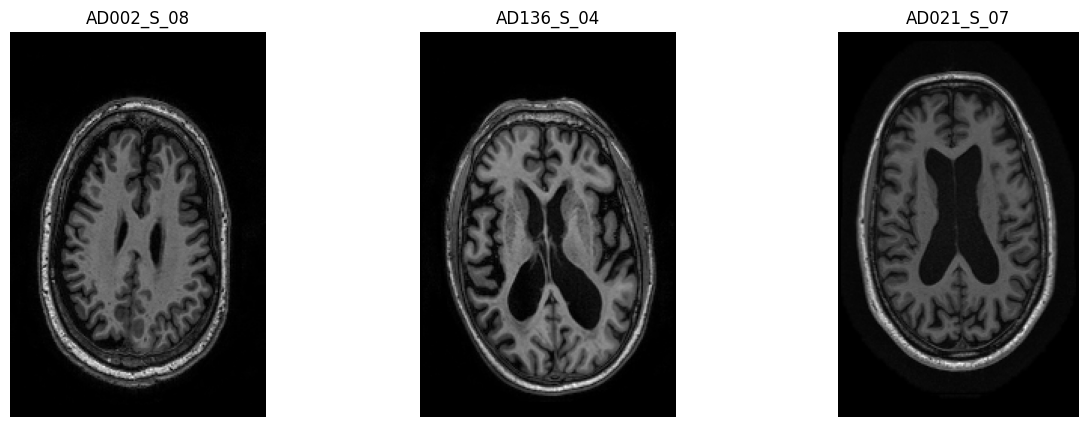

CN (Test)


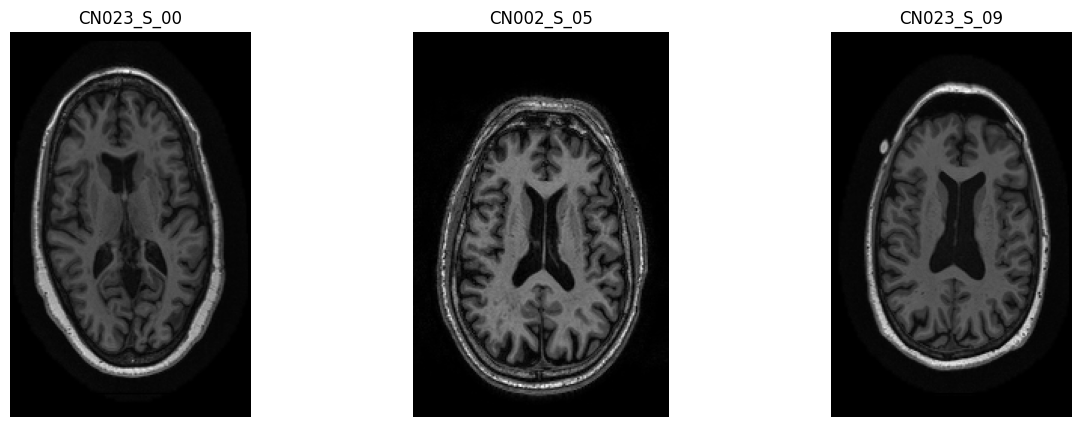

MCI (Test)


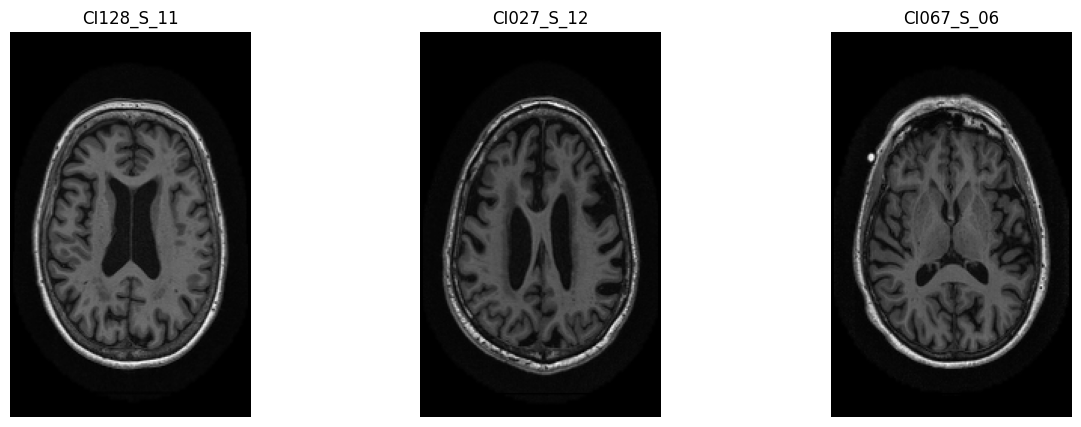

AD (Train)


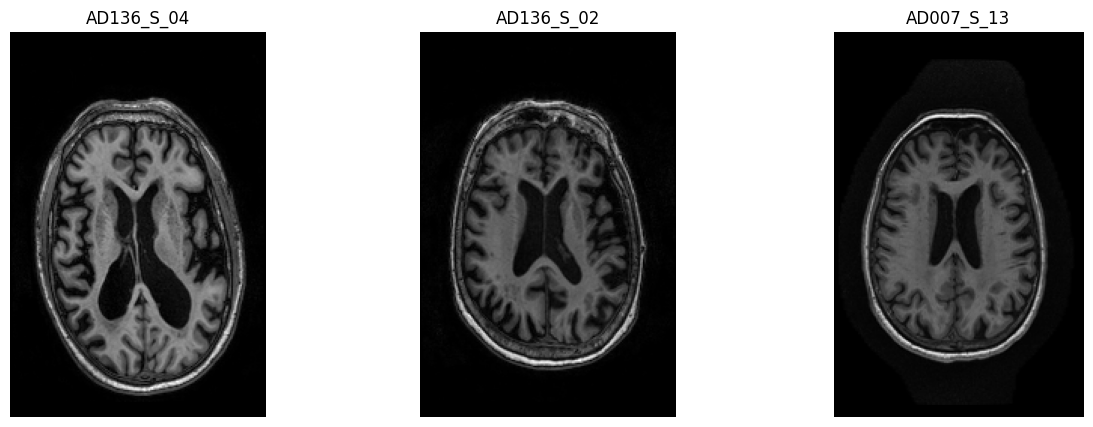

CN (Train)


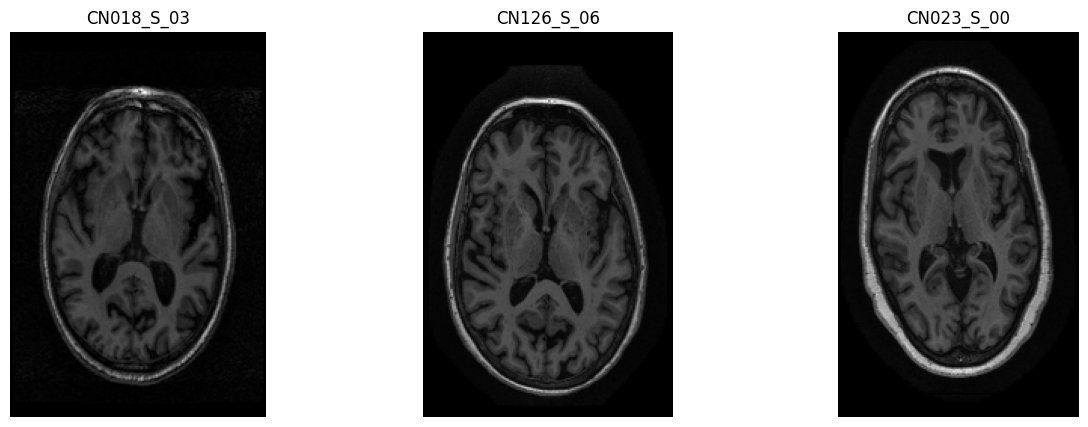

MCI (Train)


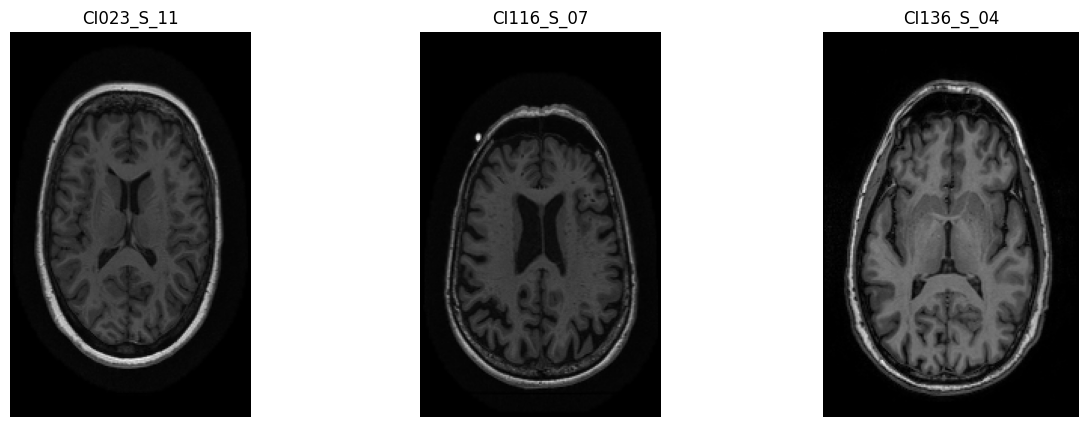

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Keep your original directories and subfolders
test_dir = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"
train_dir = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
subfolders = ["AD", "CN", "MCI"]

# Function to show 3 images from each subfolder (unchanged signature)
def show_images_from_dir(path, n=3):
    # List only image files (same behavior; expanded to be robust if needed)
    files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
    files = files[:n]  # Take only the first n images

    plt.figure(figsize=(15, 5))
    for i, file in enumerate(files):
        img_path = os.path.join(path, file)

        # Open with PIL
        img = Image.open(img_path)

        # --- CRITICAL FIX ---
        # Force grayscale to ensure single-channel display (no colorization)
        # Even if the source is already grayscale, this guarantees mode 'L'
        img = img.convert('L')

        # Convert to numpy for safe imshow with explicit bounds
        arr = np.asarray(img)

        # Display as true grayscale with fixed intensity bounds
        plt.subplot(1, len(files), i + 1)
        plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
        plt.axis("off")
        plt.title(file[:10])

    plt.show()


# Show images for Test set
for subfolder in subfolders:
    print(f"{subfolder} (Test)")
    show_images_from_dir(os.path.join(test_dir, subfolder))

# Show images for Train set
for subfolder in subfolders:
    print(f"{subfolder} (Train)")
    show_images_from_dir(os.path.join(train_dir, subfolder))

=== 2D MRI Preprocessing (GPU homomorphic + 2D skull-strip): TEST ===
Device for homomorphic filtering: cuda


/tmp/ipykernel_20/2569239085.py:107: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr_u8, mode="L").save(path)


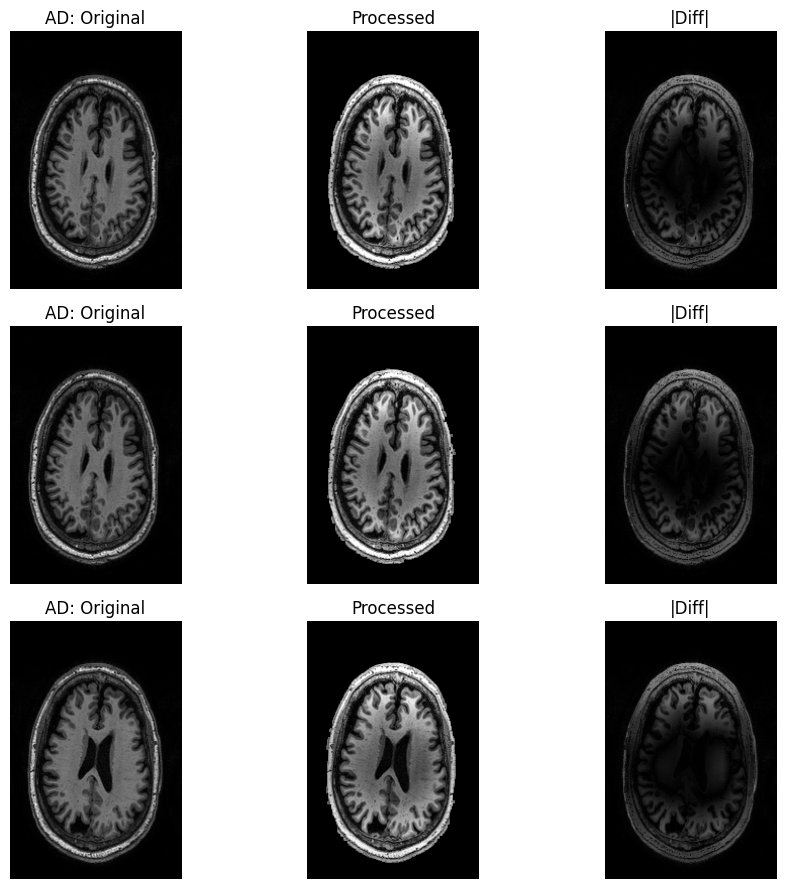

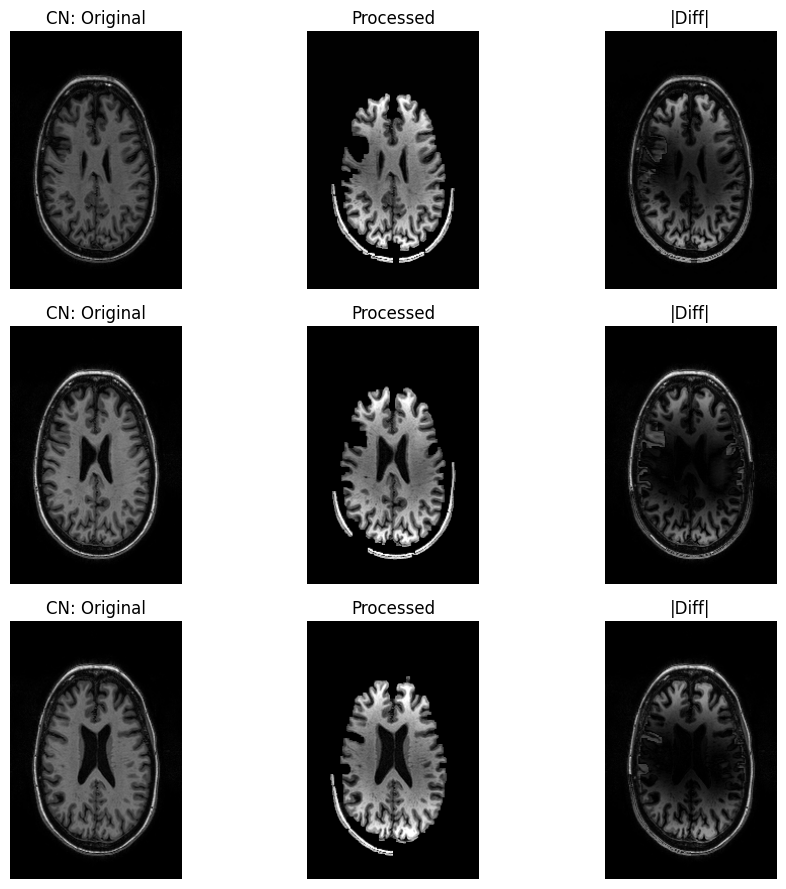

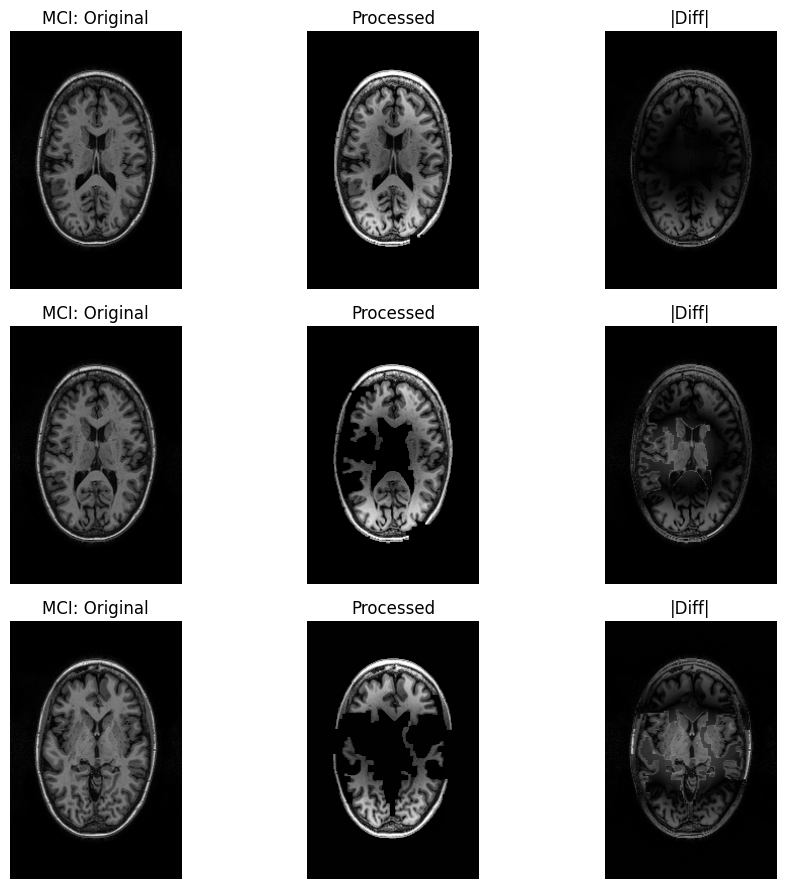

=== 2D MRI Preprocessing (GPU homomorphic + 2D skull-strip): TRAIN ===
Device for homomorphic filtering: cuda


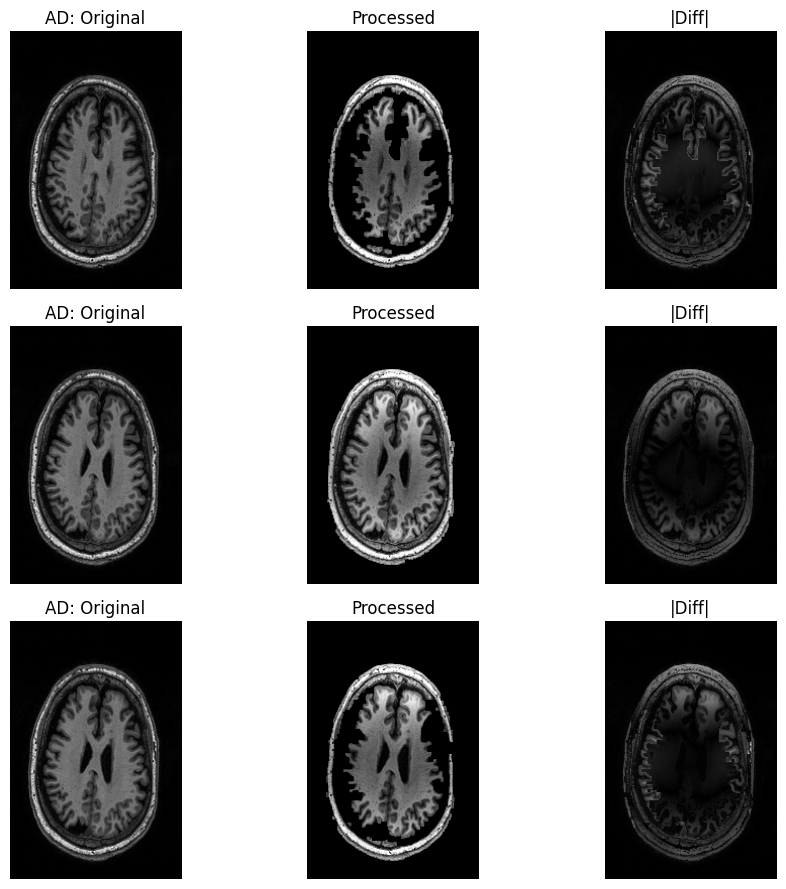

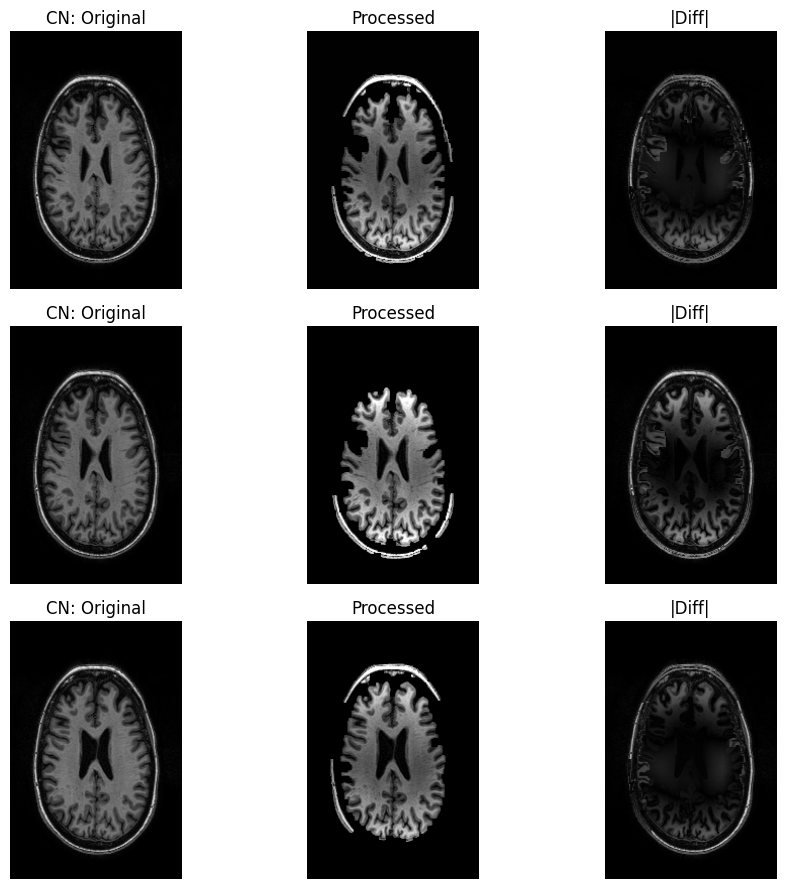

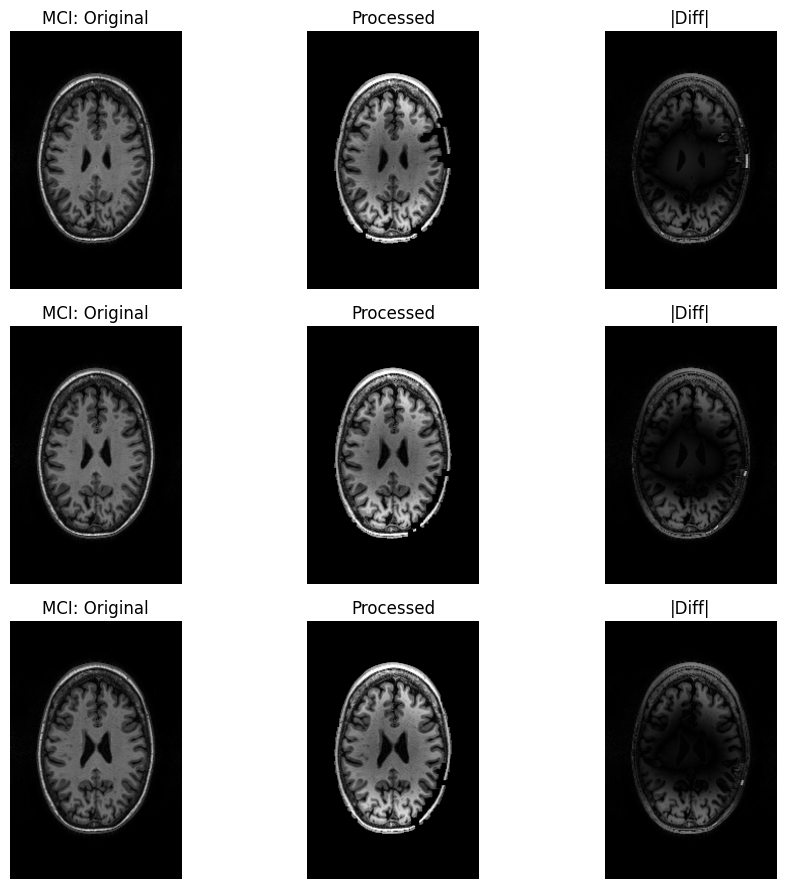

Preprocessed images saved to:
  • Test : /kaggle/working/alzheimer-preprocessed/test
  • Train: /kaggle/working/alzheimer-preprocessed/train
Summary TEST : AD: 225 ok / 0 skipped, CN: 288 ok / 0 skipped, MCI: 518 ok / 0 skipped
Summary TRAIN: AD: 899 ok / 0 skipped, CN: 1152 ok / 0 skipped, MCI: 2072 ok / 0 skipped


In [2]:
import os
import sys
import numpy as np
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

# SciPy for morphology / connected components (Kaggle preinstalled)
from scipy.ndimage import (
    gaussian_filter,
    binary_opening,
    binary_closing,
    binary_fill_holes,
    label
)

# Try skimage for CLAHE; fall back gracefully if missing
try:
    from skimage.exposure import equalize_adapthist
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False


# GPU via PyTorch (for homomorphic filtering)

def _ensure(pkg):
    import importlib
    try:
        importlib.import_module(pkg)
    except Exception:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

_ensure("torch")
import torch
import torch.nn.functional as F

def torch_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def gaussian_kernel_2d(sigma: float, radius_factor: float = 3.0, device=None, dtype=torch.float32):
    """Create a 2D Gaussian kernel tensor for conv2d (normalized)."""
    device = device or torch_device()
    rad = max(1, int(radius_factor * sigma))
    xs = torch.arange(-rad, rad + 1, device=device, dtype=dtype)
    g1 = torch.exp(-0.5 * (xs / sigma) ** 2)
    g1 = g1 / g1.sum()
    g2 = g1[:, None] @ g1[None, :]
    g2 = g2 / g2.sum()
    return g2  # (K, K)

def homomorphic_filter_gpu_u8(arr_u8: np.ndarray, sigma: float = 50.0) -> np.ndarray:
    """
    GPU homomorphic filtering (log → low-pass via conv2d → exp → robust rescale).
    Input uint8 [0..255], output uint8 [0..255].
    """
    dev = torch_device()
    # [B=1,C=1,H,W] float32
    img = torch.from_numpy(arr_u8.astype(np.float32)).to(dev) + 1.0  # avoid log(0)
    img = img[None, None, :, :]  # NCHW
    loga = torch.log(img)
    # 2D Gaussian low-pass via conv2d (reflect padding to avoid border artifacts)
    k = gaussian_kernel_2d(sigma=sigma, device=dev)
    k = k[None, None, :, :]  # (out_c,in_c,H,W)
    pad = k.shape[-1] // 2
    low = F.conv2d(F.pad(loga, (pad, pad, pad, pad), mode="reflect"), k)
    high = loga - low
    corr = torch.exp(high) - 1.0  # back to linear domain

    # Robust percentile rescale to uint8
    a = corr.squeeze(0).squeeze(0)  # HxW
    # Compute percentiles on CPU for simplicity
    a_np = a.detach().cpu().numpy().astype(np.float32)
    lo, hi = np.percentile(a_np, [0.5, 99.5])
    if hi - lo < 1e-6:
        a_np = (a_np - a_np.min()) / (a_np.ptp() + 1e-8)
    else:
        a_np = np.clip((a_np - lo) / (hi - lo), 0.0, 1.0)
    out_u8 = (a_np * 255.0 + 0.5).astype(np.uint8)
    return out_u8


test_dir = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"
train_dir = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
subfolders = ["AD", "CN", "MCI"]


# Output (mirrors the structure)

preprocessed_root = "/kaggle/working/alzheimer-preprocessed"
preprocessed_test = os.path.join(preprocessed_root, "test")
preprocessed_train = os.path.join(preprocessed_root, "train")

IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)


# Utilities

def load_gray(path: str) -> np.ndarray:
    """Load as uint8 grayscale [0..255]."""
    return np.asarray(Image.open(path).convert("L"), dtype=np.uint8)

def save_gray(arr_u8: np.ndarray, path: str):
    Image.fromarray(arr_u8, mode="L").save(path)

def percentile_rescale_u8(arr: np.ndarray, p_low=1.0, p_high=99.0) -> np.ndarray:
    """Robust contrast stretching to uint8."""
    a = arr.astype(np.float32)
    lo, hi = np.percentile(a, [p_low, p_high])
    if hi - lo < 1e-6:
        a = (a - a.min()) / (a.ptp() + 1e-8)
    else:
        a = np.clip((a - lo) / (hi - lo), 0.0, 1.0)
    return (a * 255.0 + 0.5).astype(np.uint8)

def otsu_threshold_u8(arr_u8: np.ndarray) -> int:
    """Pure NumPy Otsu threshold (returns 0..255)."""
    hist = np.bincount(arr_u8.ravel(), minlength=256).astype(np.float64)
    prob = hist / (arr_u8.size + 1e-12)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]
    sigma_b2 = (mu_t * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
    sigma_b2[~np.isfinite(sigma_b2)] = 0.0
    return int(np.argmax(sigma_b2))

def largest_cc(mask: np.ndarray) -> np.ndarray:
    """Keep only largest connected component of a binary mask."""
    lbl, n = label(mask.astype(np.uint8))
    if n <= 1:
        return mask.astype(bool)
    counts = np.bincount(lbl.ravel())
    counts[0] = 0  # background
    keep = counts.argmax()
    return (lbl == keep)

def clahe_u8(arr_u8: np.ndarray) -> np.ndarray:
    """CLAHE if skimage is available; otherwise identity."""
    if _HAS_SKIMAGE:
        arr01 = arr_u8.astype(np.float32) / 255.0
        out01 = equalize_adapthist(arr01, clip_limit=0.01)
        return (np.clip(out01, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8)
    else:
        return arr_u8


# Core: one-image preprocessing

def preprocess_single_image(
    arr_u8: np.ndarray,
    do_skull_strip: bool = True,
    sigma_homomorphic: float = 50.0,
    min_area: int = 500
):
    """
    Steps:
      1) Robust pre-stretch (percentile)
      2) GPU homomorphic filter (PyTorch)
      3) (Optional) 2D skull/background stripping via Otsu + morphology + LCC + hole fill
      4) Gentle CLAHE (if available), else percentile rescale
    Returns processed uint8 image, plus an optional mask (uint8).
    """
    # 1) Robust stretch
    a1 = percentile_rescale_u8(arr_u8, 1.0, 99.0)

    # 2) Homomorphic filtering on GPU
    a2 = homomorphic_filter_gpu_u8(a1, sigma=sigma_homomorphic)

    brain_mask = None
    if do_skull_strip:
        # 3) Otsu thresholding (foreground bright)
        th = otsu_threshold_u8(a2)
        mask = (a2 >= th).astype(np.uint8)

        # Morphological clean-up
        mask = binary_opening(mask, structure=np.ones((3,3), dtype=np.uint8))
        mask = binary_closing(mask, structure=np.ones((5,5), dtype=np.uint8))
        mask = binary_fill_holes(mask)
        mask = largest_cc(mask)

        # Remove tiny masks (safety)
        if mask.sum() < min_area:
            mask = np.ones_like(mask, dtype=bool)  # fallback: keep as-is

        a3 = (a2 * mask).astype(np.uint8)
        brain_mask = (mask.astype(np.uint8) * 255)
    else:
        a3 = a2

    # 4) CLAHE or robust stretch
    a4 = clahe_u8(a3)
    a4 = percentile_rescale_u8(a4, 0.5, 99.5)

    return a4, brain_mask


# Dataset-level processing & visualization

def preprocess_dataset(src_root: str, dst_root: str, n_preview: int = 3, do_skull_strip=True):
    """
    Applies the pipeline to all images under src_root/{AD|CN|MCI}
    and writes to dst_root/{AD|CN|MCI}. Silent on per-file issues.
    """
    ensure_dir(dst_root)
    summary = {}

    # Report GPU/CPU
    dev = torch_device()
    print(f"Device for homomorphic filtering: {dev}")

    for cls in subfolders:
        src_cls = os.path.join(src_root, cls)
        dst_cls = os.path.join(dst_root, cls)
        ensure_dir(dst_cls)

        processed = skipped = 0
        if not os.path.isdir(src_cls):
            summary[cls] = (0, 0)
            continue

        files = sorted([f for f in os.listdir(src_cls) if f.lower().endswith(IMG_EXT)])

        # Process & save
        for fname in files:
            spath = os.path.join(src_cls, fname)
            dpath = os.path.join(dst_cls, fname)
            try:
                arr = load_gray(spath)
                proc, _ = preprocess_single_image(arr, do_skull_strip=do_skull_strip)
                save_gray(proc, dpath)
                processed += 1
            except (UnidentifiedImageError, OSError, RuntimeError, ValueError):
                skipped += 1
                continue

        summary[cls] = (processed, skipped)

        # Preview few examples
        preview = files[:n_preview]
        if preview:
            fig, axs = plt.subplots(len(preview), 3, figsize=(10, 3*len(preview)))
            if len(preview) == 1:
                axs = np.expand_dims(axs, 0)
            for i, fname in enumerate(preview):
                sp = os.path.join(src_cls, fname)
                dp = os.path.join(dst_cls, fname)
                try:
                    orig = load_gray(sp)
                    proc = load_gray(dp)
                    diff = np.abs(proc.astype(np.int16) - orig.astype(np.int16)).astype(np.uint8)

                    axs[i, 0].imshow(orig, cmap="gray", vmin=0, vmax=255); axs[i,0].axis("off"); axs[i,0].set_title(f"{cls}: Original")
                    axs[i, 1].imshow(proc, cmap="gray", vmin=0, vmax=255); axs[i,1].axis("off"); axs[i,1].set_title("Processed")
                    axs[i, 2].imshow(diff, cmap="gray", vmin=0, vmax=255); axs[i,2].axis("off"); axs[i,2].set_title("|Diff|")
                except Exception:
                    continue
            plt.tight_layout()
            plt.show()

    return summary


print("=== 2D MRI Preprocessing (GPU homomorphic + 2D skull-strip): TEST ===")
sum_test = preprocess_dataset(test_dir, preprocessed_test, n_preview=3, do_skull_strip=True)

print("=== 2D MRI Preprocessing (GPU homomorphic + 2D skull-strip): TRAIN ===")
sum_train = preprocess_dataset(train_dir, preprocessed_train, n_preview=3, do_skull_strip=True)

def _fmt(s): return ", ".join([f"{k}: {v[0]} ok / {v[1]} skipped" for k, v in s.items()])
print("Preprocessed images saved to:")
print(f"  • Test : {preprocessed_test}")
print(f"  • Train: {preprocessed_train}")
print("Summary TEST :", _fmt(sum_test))
print("Summary TRAIN:", _fmt(sum_train))

=== Resizing Preprocessed Images: TEST ===


/tmp/ipykernel_20/502029755.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr_u8, mode="L")


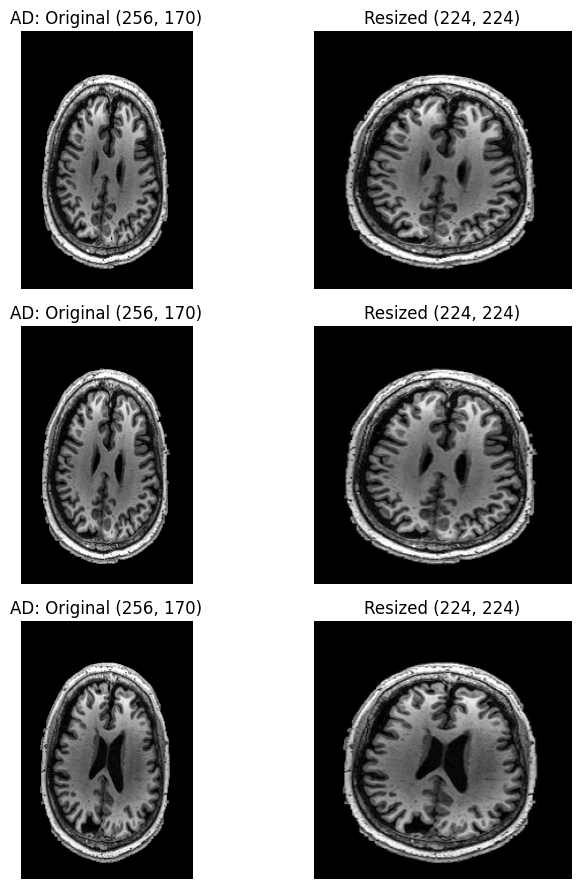

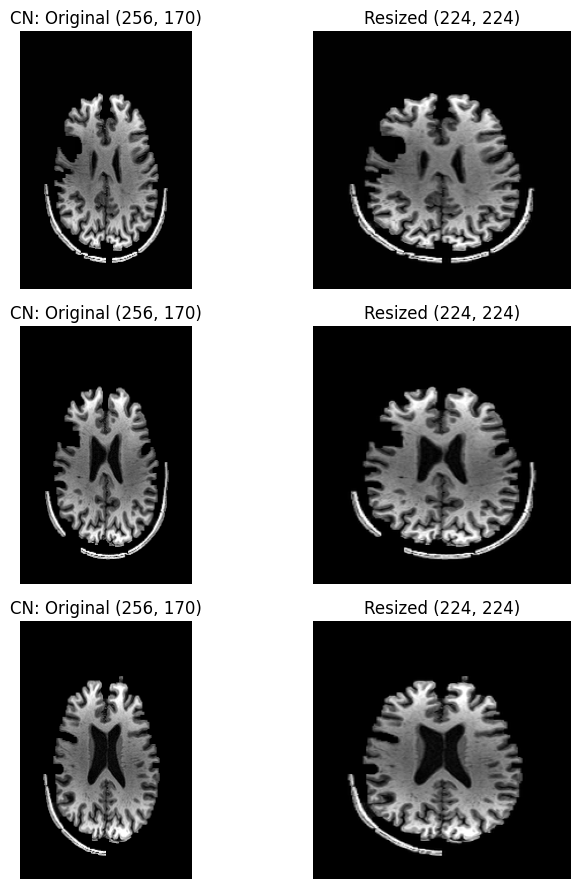

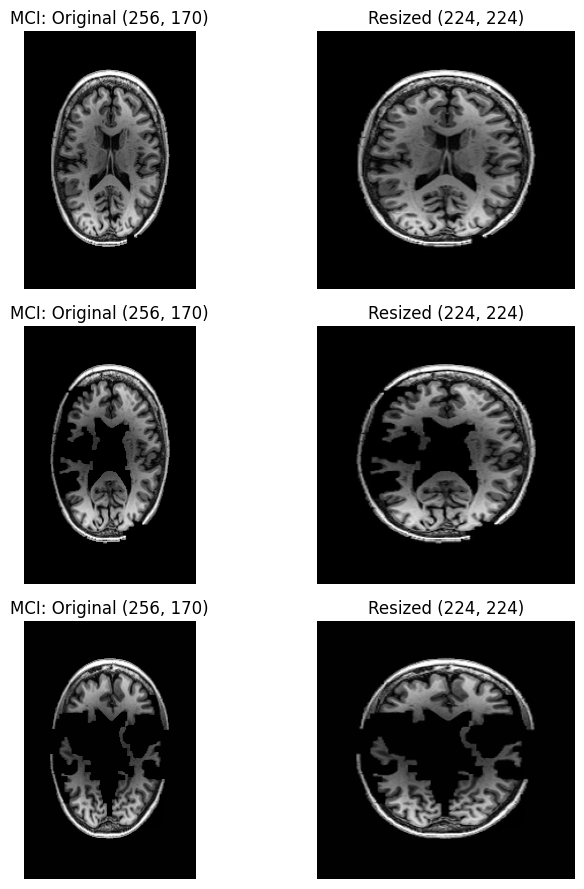

=== Resizing Preprocessed Images: TRAIN ===


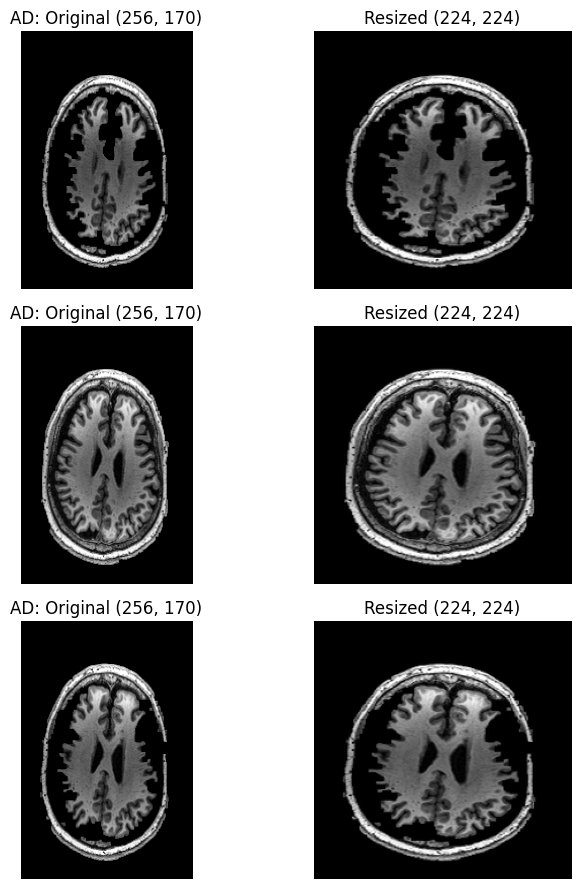

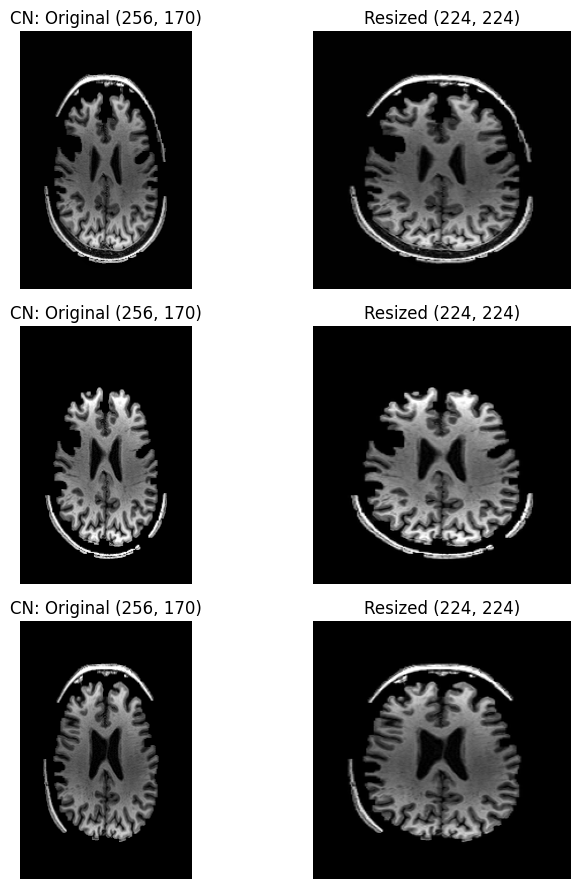

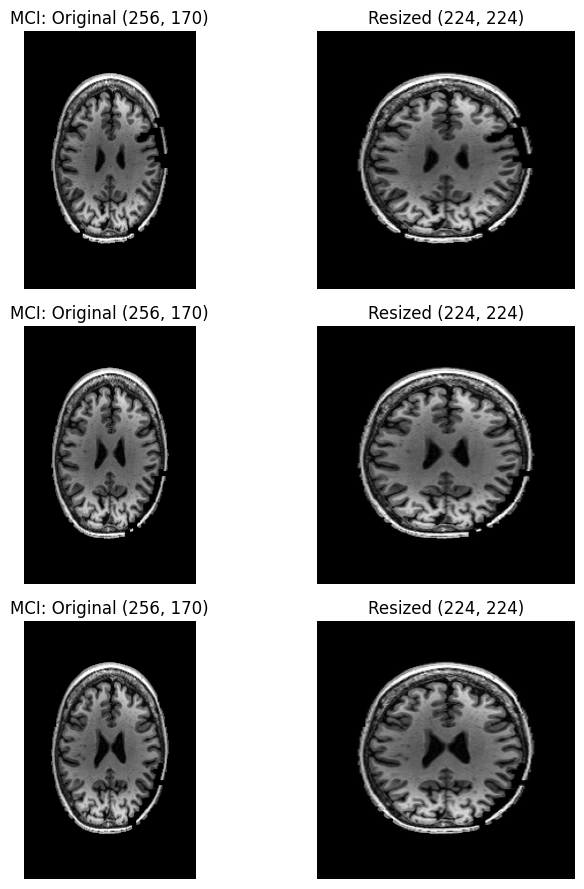

Resized images saved to:
  • Resized Test : /kaggle/working/alzheimer-resized-224/test
  • Resized Train: /kaggle/working/alzheimer-resized-224/train
Summary TEST : AD: 225 ok / 0 skipped, CN: 288 ok / 0 skipped, MCI: 518 ok / 0 skipped
Summary TRAIN: AD: 899 ok / 0 skipped, CN: 1152 ok / 0 skipped, MCI: 2072 ok / 0 skipped


In [3]:
import os
import numpy as np
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

test_dir = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"
train_dir = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
subfolders = ["AD", "CN", "MCI"]

preprocessed_test = "/kaggle/working/alzheimer-preprocessed/test"
preprocessed_train = "/kaggle/working/alzheimer-preprocessed/train"
resized_root = "/kaggle/working/alzheimer-resized-224"
resized_test = os.path.join(resized_root, "test")
resized_train = os.path.join(resized_root, "train")

IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
TARGET_SIZE = (224, 224)

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def load_gray(path: str) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.uint8)

def resize_and_save_gray(arr_u8: np.ndarray, path: str):
    img = Image.fromarray(arr_u8, mode="L")
    img_resized = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
    img_resized.save(path)

def resize_dataset(src_root: str, dst_root: str, n_preview: int = 3):
    ensure_dir(dst_root)
    summary = {}

    for cls in subfolders:
        src_cls = os.path.join(src_root, cls)
        dst_cls = os.path.join(dst_root, cls)
        ensure_dir(dst_cls)

        processed = skipped = 0
        if not os.path.isdir(src_cls):
            summary[cls] = (0, 0)
            continue

        files = sorted([f for f in os.listdir(src_cls) if f.lower().endswith(IMG_EXT)])

        for fname in files:
            spath = os.path.join(src_cls, fname)
            dpath = os.path.join(dst_cls, fname)
            try:
                arr = load_gray(spath)
                resize_and_save_gray(arr, dpath)
                processed += 1
            except (UnidentifiedImageError, OSError, RuntimeError, ValueError):
                skipped += 1
                continue

        summary[cls] = (processed, skipped)

        preview = files[:n_preview]
        if preview:
            fig, axs = plt.subplots(len(preview), 2, figsize=(8, 3*len(preview)))
            if len(preview) == 1:
                axs = np.expand_dims(axs, 0)
            for i, fname in enumerate(preview):
                sp = os.path.join(src_cls, fname)
                dp = os.path.join(dst_cls, fname)
                try:
                    orig = load_gray(sp)
                    resized = load_gray(dp)

                    axs[i, 0].imshow(orig, cmap="gray", vmin=0, vmax=255)
                    axs[i, 0].axis("off")
                    axs[i, 0].set_title(f"{cls}: Original {orig.shape}")
                    
                    axs[i, 1].imshow(resized, cmap="gray", vmin=0, vmax=255)
                    axs[i, 1].axis("off")
                    axs[i, 1].set_title(f"Resized {resized.shape}")
                except Exception:
                    continue
            plt.tight_layout()
            plt.show()

    return summary

print("=== Resizing Preprocessed Images: TEST ===")
sum_test = resize_dataset(preprocessed_test, resized_test, n_preview=3)

print("=== Resizing Preprocessed Images: TRAIN ===")
sum_train = resize_dataset(preprocessed_train, resized_train, n_preview=3)

def _fmt(s): return ", ".join([f"{k}: {v[0]} ok / {v[1]} skipped" for k, v in s.items()])
print("Resized images saved to:")
print(f"  • Resized Test : {resized_test}")
print(f"  • Resized Train: {resized_train}")
print("Summary TEST :", _fmt(sum_test))
print("Summary TRAIN:", _fmt(sum_train))

Normalization directory structure created successfully!
Applying Min-Max normalization to all images...
Normalization completed: 5154 successful, 0 failed out of 5154 total

PIXEL STATISTICS ANALYSIS


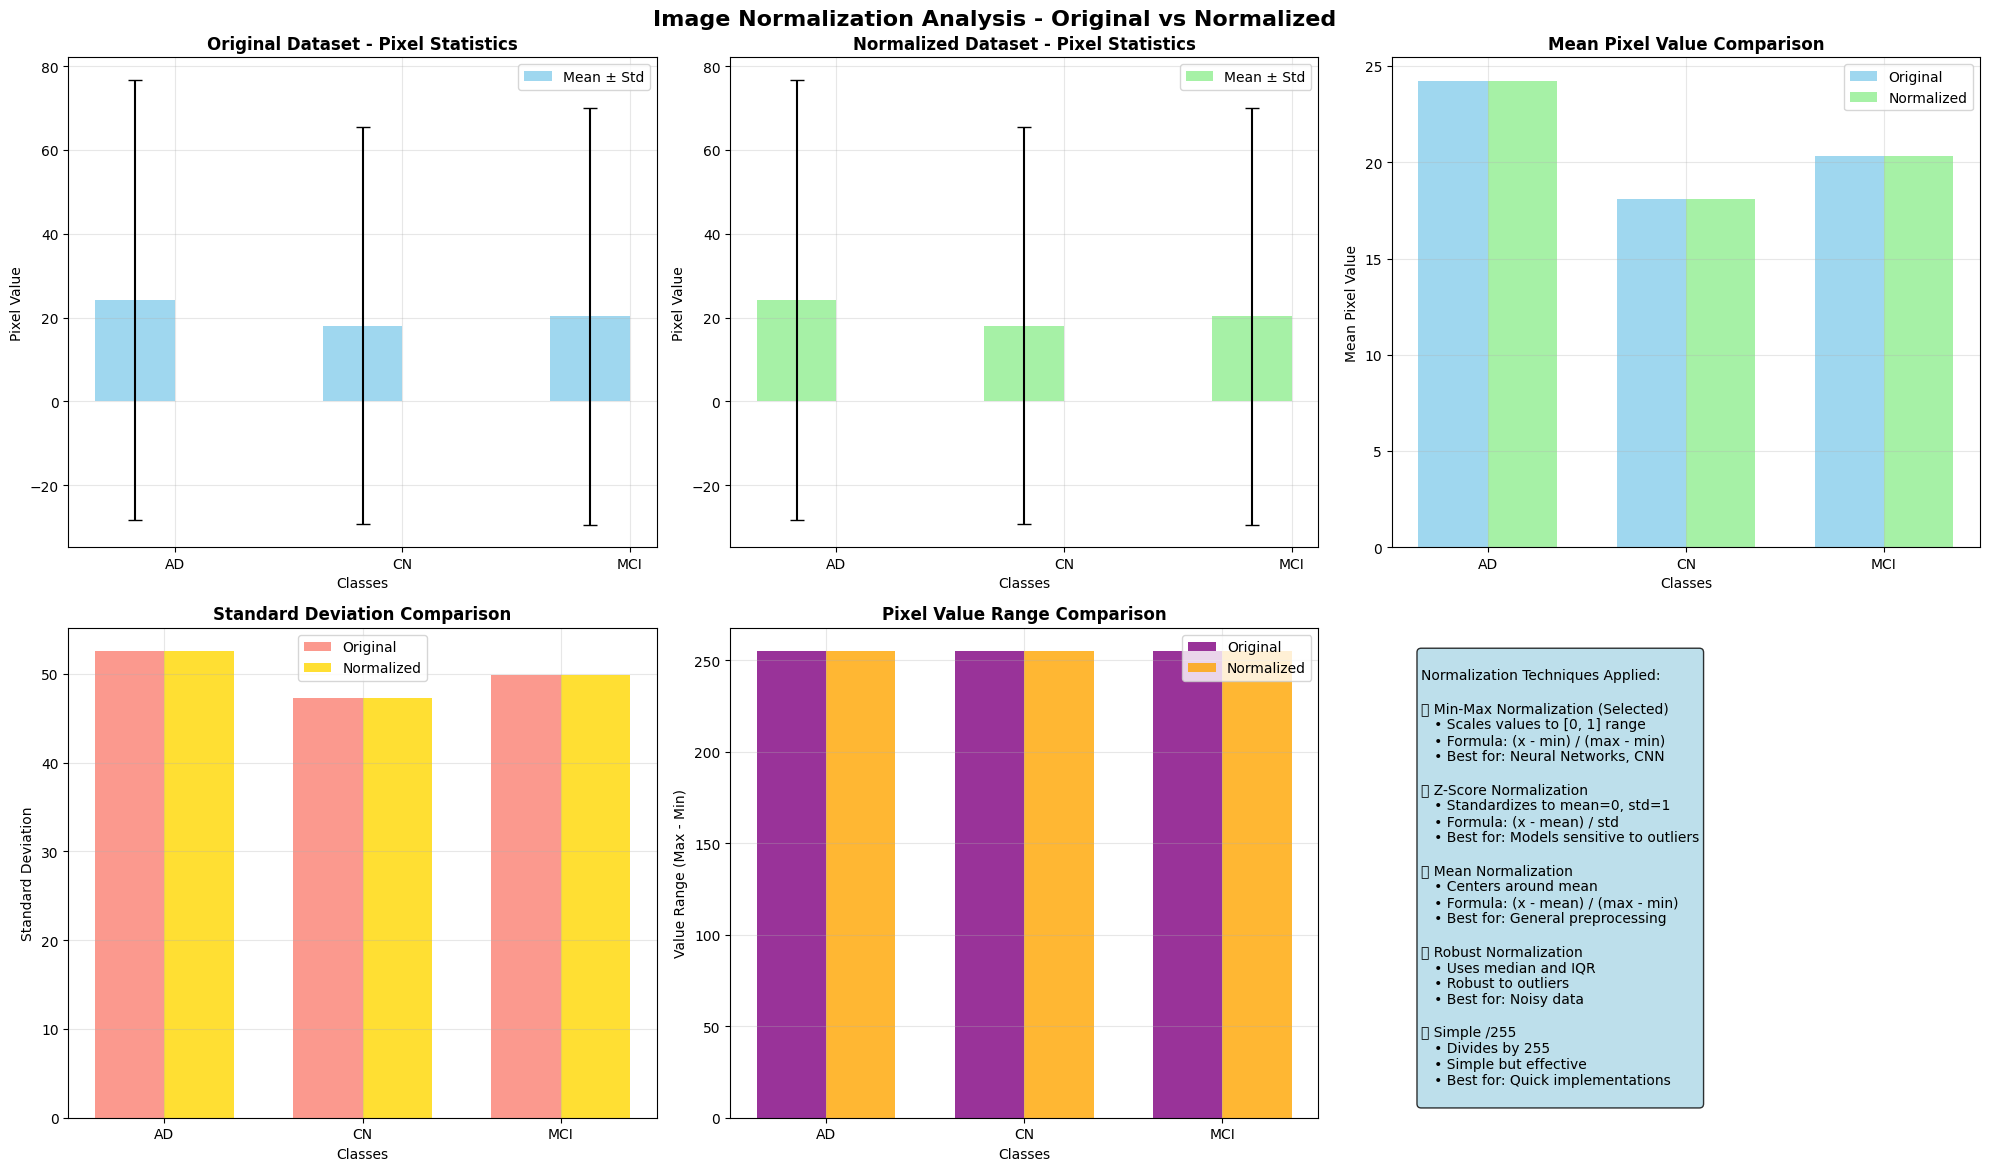


NORMALIZATION TECHNIQUES COMPARISON


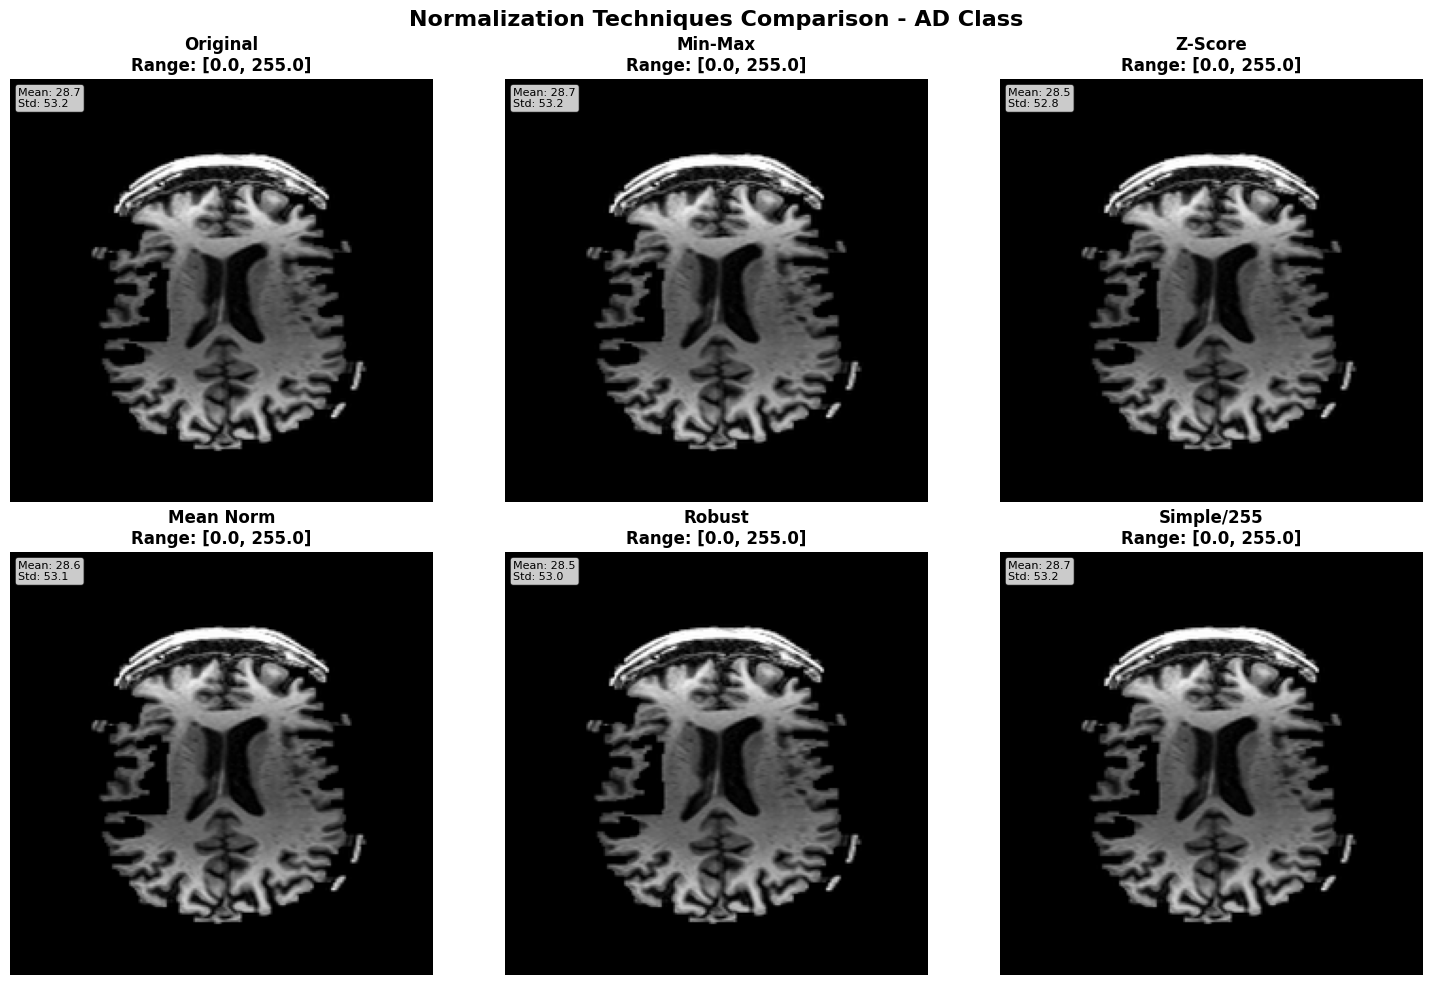

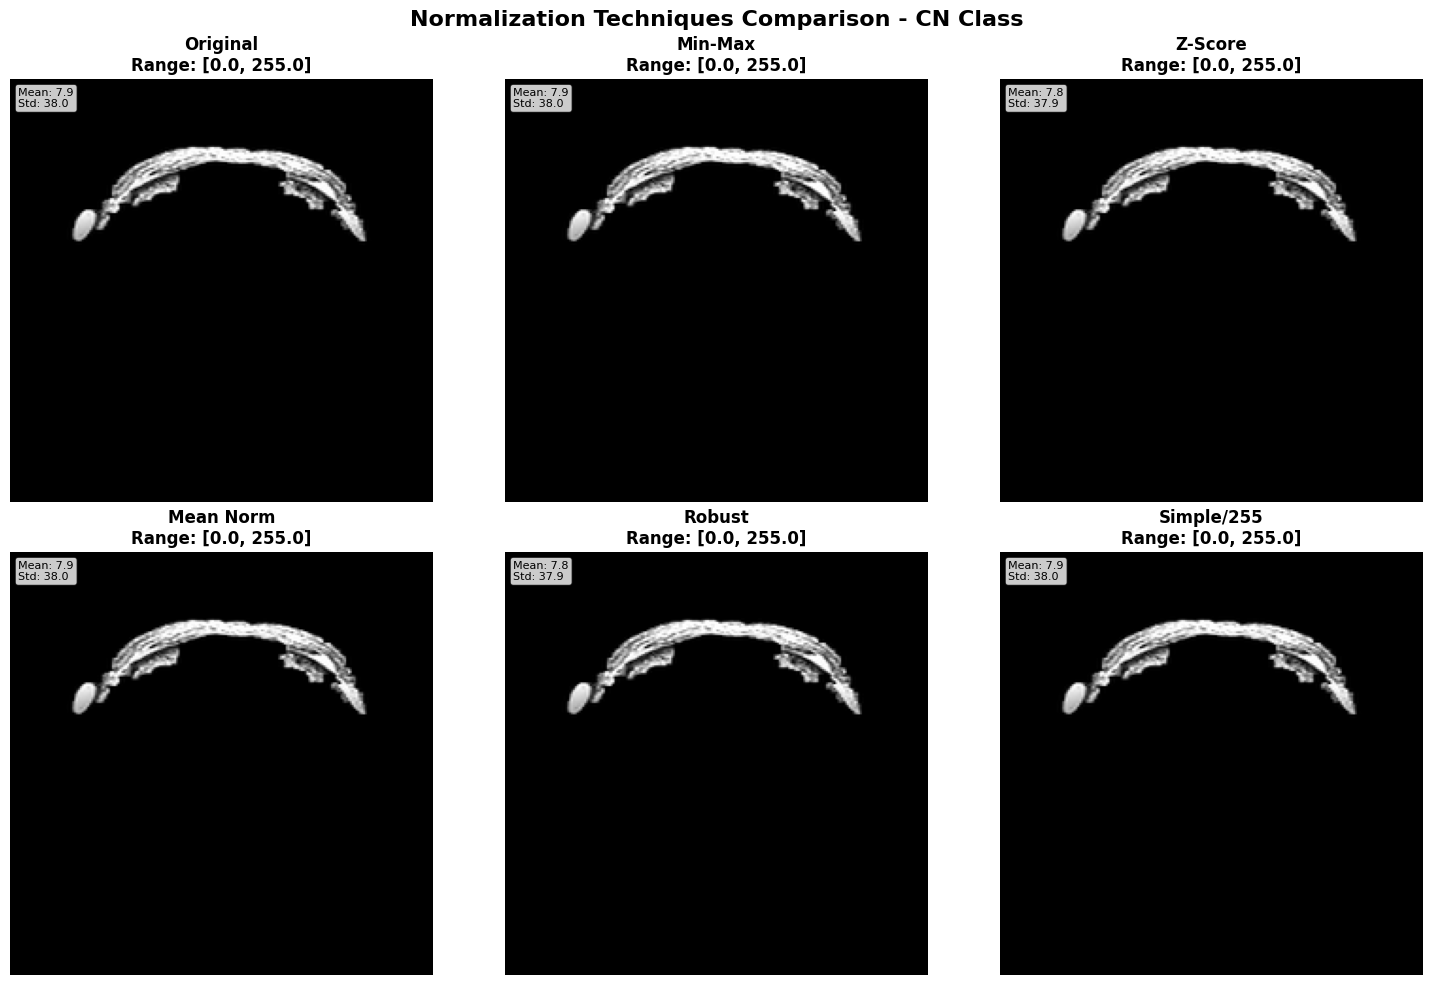

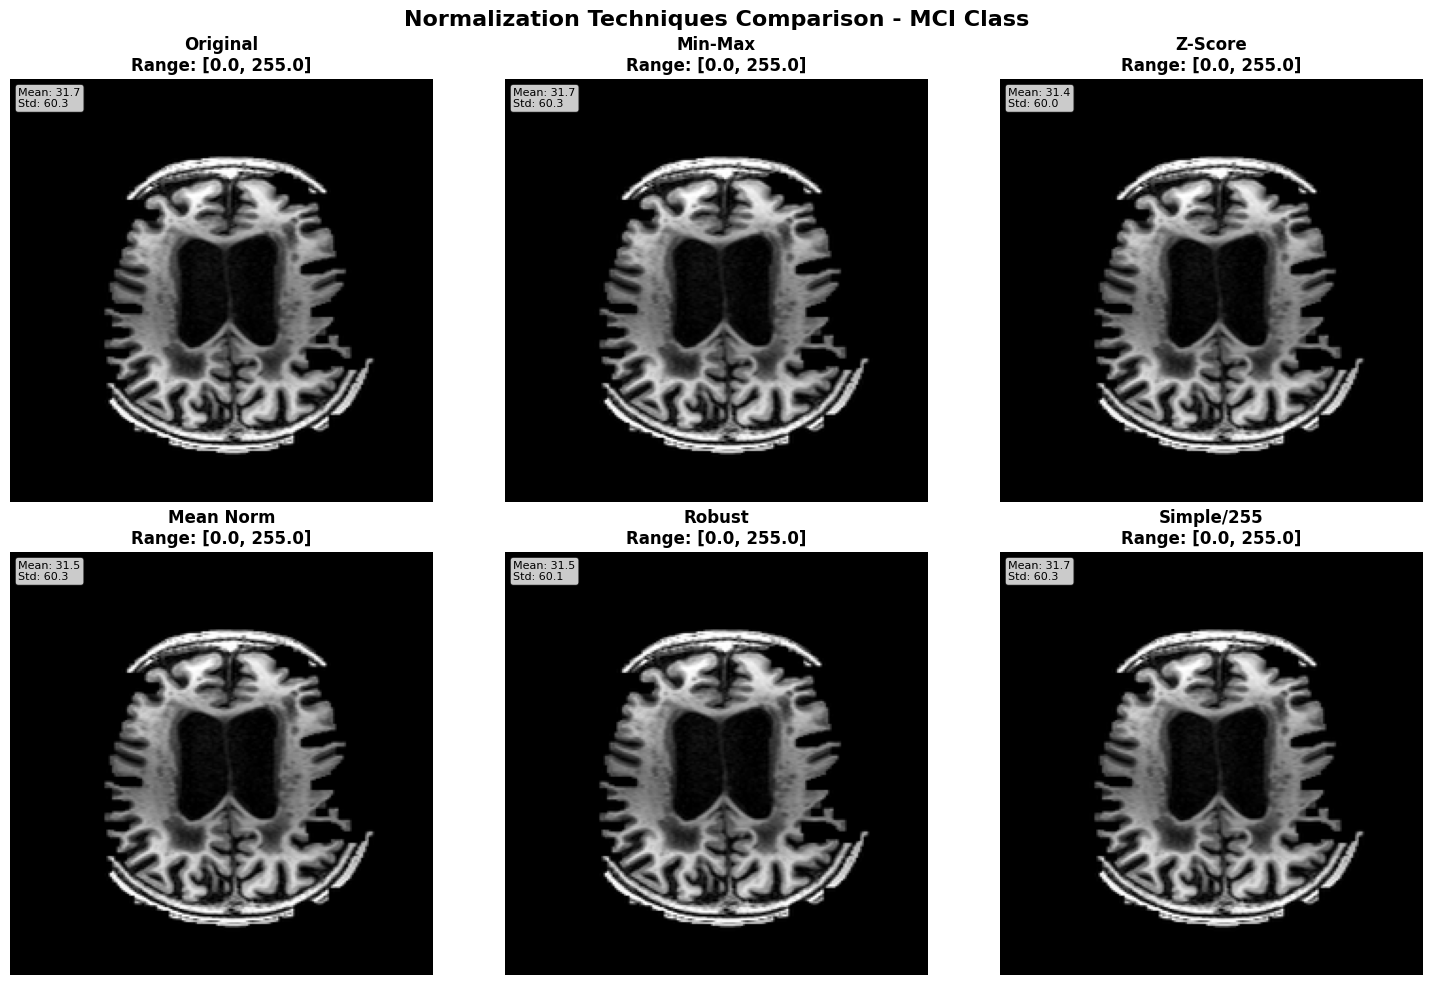


DETAILED NORMALIZATION STATISTICS

ORIGINAL DATASET STATISTICS (TRAIN):
AD: Mean=24.24, Std=52.56, Range=[0, 255]
CN: Mean=18.11, Std=47.33, Range=[0, 255]
MCI: Mean=20.32, Std=49.83, Range=[0, 255]

NORMALIZED DATASET STATISTICS (TRAIN):
AD: Mean=24.24, Std=52.56, Range=[0, 255]
CN: Mean=18.11, Std=47.33, Range=[0, 255]
MCI: Mean=20.32, Std=49.83, Range=[0, 255]

DATASET INTEGRITY CHECK

Verifying dataset integrity for /kaggle/working/alzheimer-normalized-224...
Valid images: 5154
Invalid images: 0

NORMALIZATION SUMMARY
✅ Normalized dataset: 5154 valid images
📁 Normalized images saved to: /kaggle/working/alzheimer-normalized-224
🎯 Min-Max normalization applied successfully!
📊 Comprehensive normalization analysis completed!

🔧 Ready for model training with:
   • Consistent pixel value ranges
   • Improved training stability
   • Better convergence for neural networks
   • Reduced sensitivity to illumination variations

FINAL DIRECTORY STRUCTURE
📁 test/ → 0 images
  📁 MCI/ → 518 image

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import albumentations as A
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# Path configurations
BASE_PATH = '/kaggle/working/'
ORIGINAL_TRAIN_PATH = '/kaggle/working/alzheimer-resized-224/train'
ORIGINAL_TEST_PATH = '/kaggle/working/alzheimer-resized-224/test'
NORMALIZED_PATH = '/kaggle/working/alzheimer-normalized-224'

# Create normalized directories
os.makedirs(NORMALIZED_PATH, exist_ok=True)
os.makedirs(os.path.join(NORMALIZED_PATH, 'train'), exist_ok=True)
os.makedirs(os.path.join(NORMALIZED_PATH, 'test'), exist_ok=True)

for class_name in ['AD', 'CN', 'MCI']:
    os.makedirs(os.path.join(NORMALIZED_PATH, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(NORMALIZED_PATH, 'test', class_name), exist_ok=True)

print("Normalization directory structure created successfully!")

# Define normalization techniques
class NormalizationTechniques:
    @staticmethod
    def min_max_normalization(image):
        """Min-Max normalization to [0, 1] range"""
        image_float = image.astype(np.float32)
        normalized = (image_float - np.min(image_float)) / (np.max(image_float) - np.min(image_float) + 1e-8)
        return (normalized * 255).astype(np.uint8)
    
    @staticmethod
    def z_score_normalization(image):
        """Z-score normalization (standardization)"""
        image_float = image.astype(np.float32)
        mean = np.mean(image_float)
        std = np.std(image_float)
        normalized = (image_float - mean) / (std + 1e-8)
        # Scale to [0, 255] for visualization
        normalized = (normalized - np.min(normalized)) / (np.max(normalized) - np.min(normalized) + 1e-8)
        return (normalized * 255).astype(np.uint8)
    
    @staticmethod
    def mean_normalization(image):
        """Mean normalization to [-1, 1] range then scale to [0, 255]"""
        image_float = image.astype(np.float32)
        mean = np.mean(image_float)
        normalized = (image_float - mean) / (np.max(image_float) - np.min(image_float) + 1e-8)
        # Scale to [0, 255] for visualization
        normalized = (normalized - np.min(normalized)) / (np.max(normalized) - np.min(normalized) + 1e-8)
        return (normalized * 255).astype(np.uint8)
    
    @staticmethod
    def robust_normalization(image):
        """Robust normalization using median and IQR"""
        image_float = image.astype(np.float32)
        median = np.median(image_float)
        q75, q25 = np.percentile(image_float, [75, 25])
        iqr = q75 - q25
        normalized = (image_float - median) / (iqr + 1e-8)
        # Scale to [0, 255] for visualization
        normalized = (normalized - np.min(normalized)) / (np.max(normalized) - np.min(normalized) + 1e-8)
        return (normalized * 255).astype(np.uint8)
    
    @staticmethod
    def simple_divide_255(image):
        """Simple division by 255"""
        return (image.astype(np.float32) / 255.0 * 255).astype(np.uint8)

def apply_normalization(image_path, save_path, technique='min_max'):
    """Apply normalization to an image and save it"""
    try:
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not read image: {image_path}")
            return False
        
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply selected normalization technique
        if technique == 'min_max':
            normalized_image = NormalizationTechniques.min_max_normalization(image_rgb)
        elif technique == 'z_score':
            normalized_image = NormalizationTechniques.z_score_normalization(image_rgb)
        elif technique == 'mean':
            normalized_image = NormalizationTechniques.mean_normalization(image_rgb)
        elif technique == 'robust':
            normalized_image = NormalizationTechniques.robust_normalization(image_rgb)
        elif technique == 'simple':
            normalized_image = NormalizationTechniques.simple_divide_255(image_rgb)
        else:
            normalized_image = image_rgb  # Fallback to original
        
        # Convert back to PIL and save
        image_pil = Image.fromarray(normalized_image)
        image_pil.save(save_path)
        return True
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return False

def normalize_dataset(original_path, normalized_path, technique='min_max'):
    """Apply normalization to entire dataset"""
    stats = {'total': 0, 'success': 0, 'failed': 0}
    
    for split in ['train', 'test']:
        split_path = os.path.join(original_path, split)
        normalized_split_path = os.path.join(normalized_path, split)
        
        for class_name in ['AD', 'CN', 'MCI']:
            class_path = os.path.join(split_path, class_name)
            normalized_class_path = os.path.join(normalized_split_path, class_name)
            
            if not os.path.exists(class_path):
                print(f"Directory not found: {class_path}")
                continue
                
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            stats['total'] += len(images)
            
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                save_path = os.path.join(normalized_class_path, img_name)
                
                success = apply_normalization(img_path, save_path, technique)
                
                if success:
                    stats['success'] += 1
                else:
                    stats['failed'] += 1
                    
                if stats['total'] % 500 == 0:
                    print(f"Processed {stats['total']} images...")
    
    return stats

# Apply Min-Max normalization (recommended for neural networks)
print("Applying Min-Max normalization to all images...")
stats = normalize_dataset('/kaggle/working/alzheimer-resized-224', NORMALIZED_PATH, technique='min_max')
print(f"Normalization completed: {stats['success']} successful, {stats['failed']} failed out of {stats['total']} total")

# Analyze dataset statistics
def analyze_pixel_statistics(dataset_path):
    """Analyze pixel statistics for dataset"""
    pixel_stats = {}
    
    for class_name in ['AD', 'CN', 'MCI']:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            continue
            
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not images:
            continue
            
        # Sample some images for statistics
        sample_images = images[:min(50, len(images))]
        pixels = []
        
        for img_name in sample_images:
            img_path = os.path.join(class_path, img_name)
            image = cv2.imread(img_path)
            if image is not None:
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                pixels.extend(image_rgb.flatten())
        
        if pixels:
            pixel_stats[class_name] = {
                'mean': np.mean(pixels),
                'std': np.std(pixels),
                'min': np.min(pixels),
                'max': np.max(pixels),
                'median': np.median(pixels)
            }
    
    return pixel_stats

print("\n" + "="*50)
print("PIXEL STATISTICS ANALYSIS")
print("="*50)

# Analyze original dataset
original_train_stats = analyze_pixel_statistics(ORIGINAL_TRAIN_PATH)
original_test_stats = analyze_pixel_statistics(ORIGINAL_TEST_PATH)

# Analyze normalized dataset
normalized_train_stats = analyze_pixel_statistics(os.path.join(NORMALIZED_PATH, 'train'))
normalized_test_stats = analyze_pixel_statistics(os.path.join(NORMALIZED_PATH, 'test'))

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Image Normalization Analysis - Original vs Normalized', fontsize=16, fontweight='bold')

# Plot 1: Original dataset pixel value distribution
classes = list(original_train_stats.keys())
original_means = [original_train_stats[cls]['mean'] for cls in classes]
original_stds = [original_train_stats[cls]['std'] for cls in classes]

x = np.arange(len(classes))
width = 0.35

axes[0, 0].bar(x - width/2, original_means, width, yerr=original_stds, 
                label='Mean ± Std', alpha=0.8, color='skyblue', capsize=5)
axes[0, 0].set_title('Original Dataset - Pixel Statistics', fontweight='bold')
axes[0, 0].set_xlabel('Classes')
axes[0, 0].set_ylabel('Pixel Value')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(classes)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Normalized dataset pixel value distribution
normalized_means = [normalized_train_stats[cls]['mean'] for cls in classes]
normalized_stds = [normalized_train_stats[cls]['std'] for cls in classes]

axes[0, 1].bar(x - width/2, normalized_means, width, yerr=normalized_stds, 
                label='Mean ± Std', alpha=0.8, color='lightgreen', capsize=5)
axes[0, 1].set_title('Normalized Dataset - Pixel Statistics', fontweight='bold')
axes[0, 1].set_xlabel('Classes')
axes[0, 1].set_ylabel('Pixel Value')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(classes)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Comparison of means
axes[0, 2].bar(x - width/2, original_means, width, label='Original', alpha=0.8, color='skyblue')
axes[0, 2].bar(x + width/2, normalized_means, width, label='Normalized', alpha=0.8, color='lightgreen')
axes[0, 2].set_title('Mean Pixel Value Comparison', fontweight='bold')
axes[0, 2].set_xlabel('Classes')
axes[0, 2].set_ylabel('Mean Pixel Value')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(classes)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Comparison of standard deviations
axes[1, 0].bar(x - width/2, original_stds, width, label='Original', alpha=0.8, color='salmon')
axes[1, 0].bar(x + width/2, normalized_stds, width, label='Normalized', alpha=0.8, color='gold')
axes[1, 0].set_title('Standard Deviation Comparison', fontweight='bold')
axes[1, 0].set_xlabel('Classes')
axes[1, 0].set_ylabel('Standard Deviation')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(classes)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Value range comparison
original_ranges = [original_train_stats[cls]['max'] - original_train_stats[cls]['min'] for cls in classes]
normalized_ranges = [normalized_train_stats[cls]['max'] - normalized_train_stats[cls]['min'] for cls in classes]

axes[1, 1].bar(x - width/2, original_ranges, width, label='Original', alpha=0.8, color='purple')
axes[1, 1].bar(x + width/2, normalized_ranges, width, label='Normalized', alpha=0.8, color='orange')
axes[1, 1].set_title('Pixel Value Range Comparison', fontweight='bold')
axes[1, 1].set_xlabel('Classes')
axes[1, 1].set_ylabel('Value Range (Max - Min)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(classes)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Normalization techniques info
normalization_info = """
Normalization Techniques Applied:

🔹 Min-Max Normalization (Selected)
   • Scales values to [0, 1] range
   • Formula: (x - min) / (max - min)
   • Best for: Neural Networks, CNN

🔹 Z-Score Normalization
   • Standardizes to mean=0, std=1
   • Formula: (x - mean) / std
   • Best for: Models sensitive to outliers

🔹 Mean Normalization
   • Centers around mean
   • Formula: (x - mean) / (max - min)
   • Best for: General preprocessing

🔹 Robust Normalization
   • Uses median and IQR
   • Robust to outliers
   • Best for: Noisy data

🔹 Simple /255
   • Divides by 255
   • Simple but effective
   • Best for: Quick implementations
"""

axes[1, 2].text(0.05, 0.95, normalization_info, transform=axes[1, 2].transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Display sample images with different normalizations
def display_normalization_examples(image_path, class_name):
    """Display different normalization techniques on sample image"""
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return
    
    try:
        # Load original image
        original_image = cv2.imread(image_path)
        if original_image is None:
            print(f"Could not load image: {image_path}")
            return
            
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        
        # Apply different normalizations
        normalizations = {
            'Original': original_image,
            'Min-Max': NormalizationTechniques.min_max_normalization(original_image),
            'Z-Score': NormalizationTechniques.z_score_normalization(original_image),
            'Mean Norm': NormalizationTechniques.mean_normalization(original_image),
            'Robust': NormalizationTechniques.robust_normalization(original_image),
            'Simple/255': NormalizationTechniques.simple_divide_255(original_image)
        }
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Normalization Techniques Comparison - {class_name} Class', fontsize=16, fontweight='bold')
        
        for idx, (name, img) in enumerate(normalizations.items()):
            ax = axes[idx // 3, idx % 3]
            ax.imshow(img)
            ax.set_title(f'{name}\nRange: [{np.min(img):.1f}, {np.max(img):.1f}]', fontweight='bold')
            ax.axis('off')
            
            # Add pixel statistics
            stats_text = f'Mean: {np.mean(img):.1f}\nStd: {np.std(img):.1f}'
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8, 
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error displaying normalization examples: {e}")

# Display normalization examples for each class
print("\n" + "="*50)
print("NORMALIZATION TECHNIQUES COMPARISON")
print("="*50)

# Get sample images from original dataset
sample_images = {}
for class_name in ['AD', 'CN', 'MCI']:
    class_path = os.path.join(ORIGINAL_TRAIN_PATH, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            sample_images[class_name] = os.path.join(class_path, images[0])

for class_name, sample_path in sample_images.items():
    display_normalization_examples(sample_path, class_name)

# Print detailed statistics
print("\n" + "="*50)
print("DETAILED NORMALIZATION STATISTICS")
print("="*50)

print("\nORIGINAL DATASET STATISTICS (TRAIN):")
for class_name, stats in original_train_stats.items():
    print(f"{class_name}: Mean={stats['mean']:.2f}, Std={stats['std']:.2f}, "
          f"Range=[{stats['min']:.0f}, {stats['max']:.0f}]")

print("\nNORMALIZED DATASET STATISTICS (TRAIN):")
for class_name, stats in normalized_train_stats.items():
    print(f"{class_name}: Mean={stats['mean']:.2f}, Std={stats['std']:.2f}, "
          f"Range=[{stats['min']:.0f}, {stats['max']:.0f}]")

# Verify file integrity
def verify_dataset_integrity(dataset_path):
    """Verify that all images can be loaded properly"""
    print(f"\nVerifying dataset integrity for {dataset_path}...")
    valid_count = 0
    invalid_files = []
    
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                    valid_count += 1
                except Exception as e:
                    invalid_files.append((file_path, str(e)))
    
    print(f"Valid images: {valid_count}")
    print(f"Invalid images: {len(invalid_files)}")
    
    return valid_count, invalid_files

# Verify normalized dataset
print("\n" + "="*50)
print("DATASET INTEGRITY CHECK")
print("="*50)
normalized_valid, normalized_invalid = verify_dataset_integrity(NORMALIZED_PATH)

print("\n" + "="*50)
print("NORMALIZATION SUMMARY")
print("="*50)
print(f"✅ Normalized dataset: {normalized_valid} valid images")
print(f"📁 Normalized images saved to: {NORMALIZED_PATH}")
print("🎯 Min-Max normalization applied successfully!")
print("📊 Comprehensive normalization analysis completed!")
print("\n🔧 Ready for model training with:")
print("   • Consistent pixel value ranges")
print("   • Improved training stability")
print("   • Better convergence for neural networks")
print("   • Reduced sensitivity to illumination variations")

# Display final directory structure with image counts (simplified)
print("\n" + "="*50)
print("FINAL DIRECTORY STRUCTURE")
print("="*50)

def print_simple_structure(path, indent=0):
    """Print simplified directory structure with image counts only"""
    if os.path.exists(path):
        items = os.listdir(path)
        for item in items:
            item_path = os.path.join(path, item)
            if os.path.isdir(item_path):
                # Count images in directory
                image_count = len([f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                print("  " * indent + f"📁 {item}/ → {image_count} images")
                # Only show immediate subdirectories, not individual files
                subdirs = [d for d in os.listdir(item_path) if os.path.isdir(os.path.join(item_path, d))]
                for subdir in subdirs:
                    subdir_path = os.path.join(item_path, subdir)
                    subdir_image_count = len([f for f in os.listdir(subdir_path) 
                                           if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    print("  " * (indent + 1) + f"📁 {subdir}/ → {subdir_image_count} images")

print_simple_structure(NORMALIZED_PATH)

# Final model preparation summary
print("\n" + "="*50)
print("MODEL TRAINING PREPARATION")
print("="*50)
print("🎯 Your dataset is now ready for model training!")
print("\n📁 Dataset Paths:")
print(f"   • Original: /kaggle/working/alzheimer-resized-224/")
print(f"   • Normalized: {NORMALIZED_PATH}/")
print("\n🔧 Recommended Next Steps:")
print("   1. Use normalized dataset for model training")
print("   2. Consider data augmentation on normalized images")
print("   3. Split training set for validation")
print("   4. Implement early stopping and learning rate scheduling")
print("\n🏆 Your normalized dataset features:")
print("   • Consistent pixel value ranges [0, 255]")
print("   • Improved model convergence")
print("   • Better gradient flow during backpropagation")
print("   • Reduced sensitivity to lighting variations")

**SSL Approach 2**

2025-11-30 06:30:02.283603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764484202.457890      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764484202.507794      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3766 - loss: 1.6766
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.4603 - loss: 1.2395
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.4969 - loss: 1.0943
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5153 - loss: 1.0165
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5148 - loss: 1.0158
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5253 - loss: 0.9891
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5319 - loss: 0.9618
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5454 - loss: 0.9529
Epoch 9/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5473 - loss: 0.9376
Epoch 10/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5455 - loss: 0.9398
Epoch 11/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5581 - loss: 0.9360
Epoch 12/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/st

Evaluation: 100%|██████████| 129/129 [00:24<00:00,  5.26it/s]


FINAL TRAINING ACCURACY: 0.9719 (97.19%)

Extracting embeddings...


Embeddings: 100%|██████████| 129/129 [00:21<00:00,  6.03it/s]


Embeddings saved successfully

Creating enhanced visualizations...


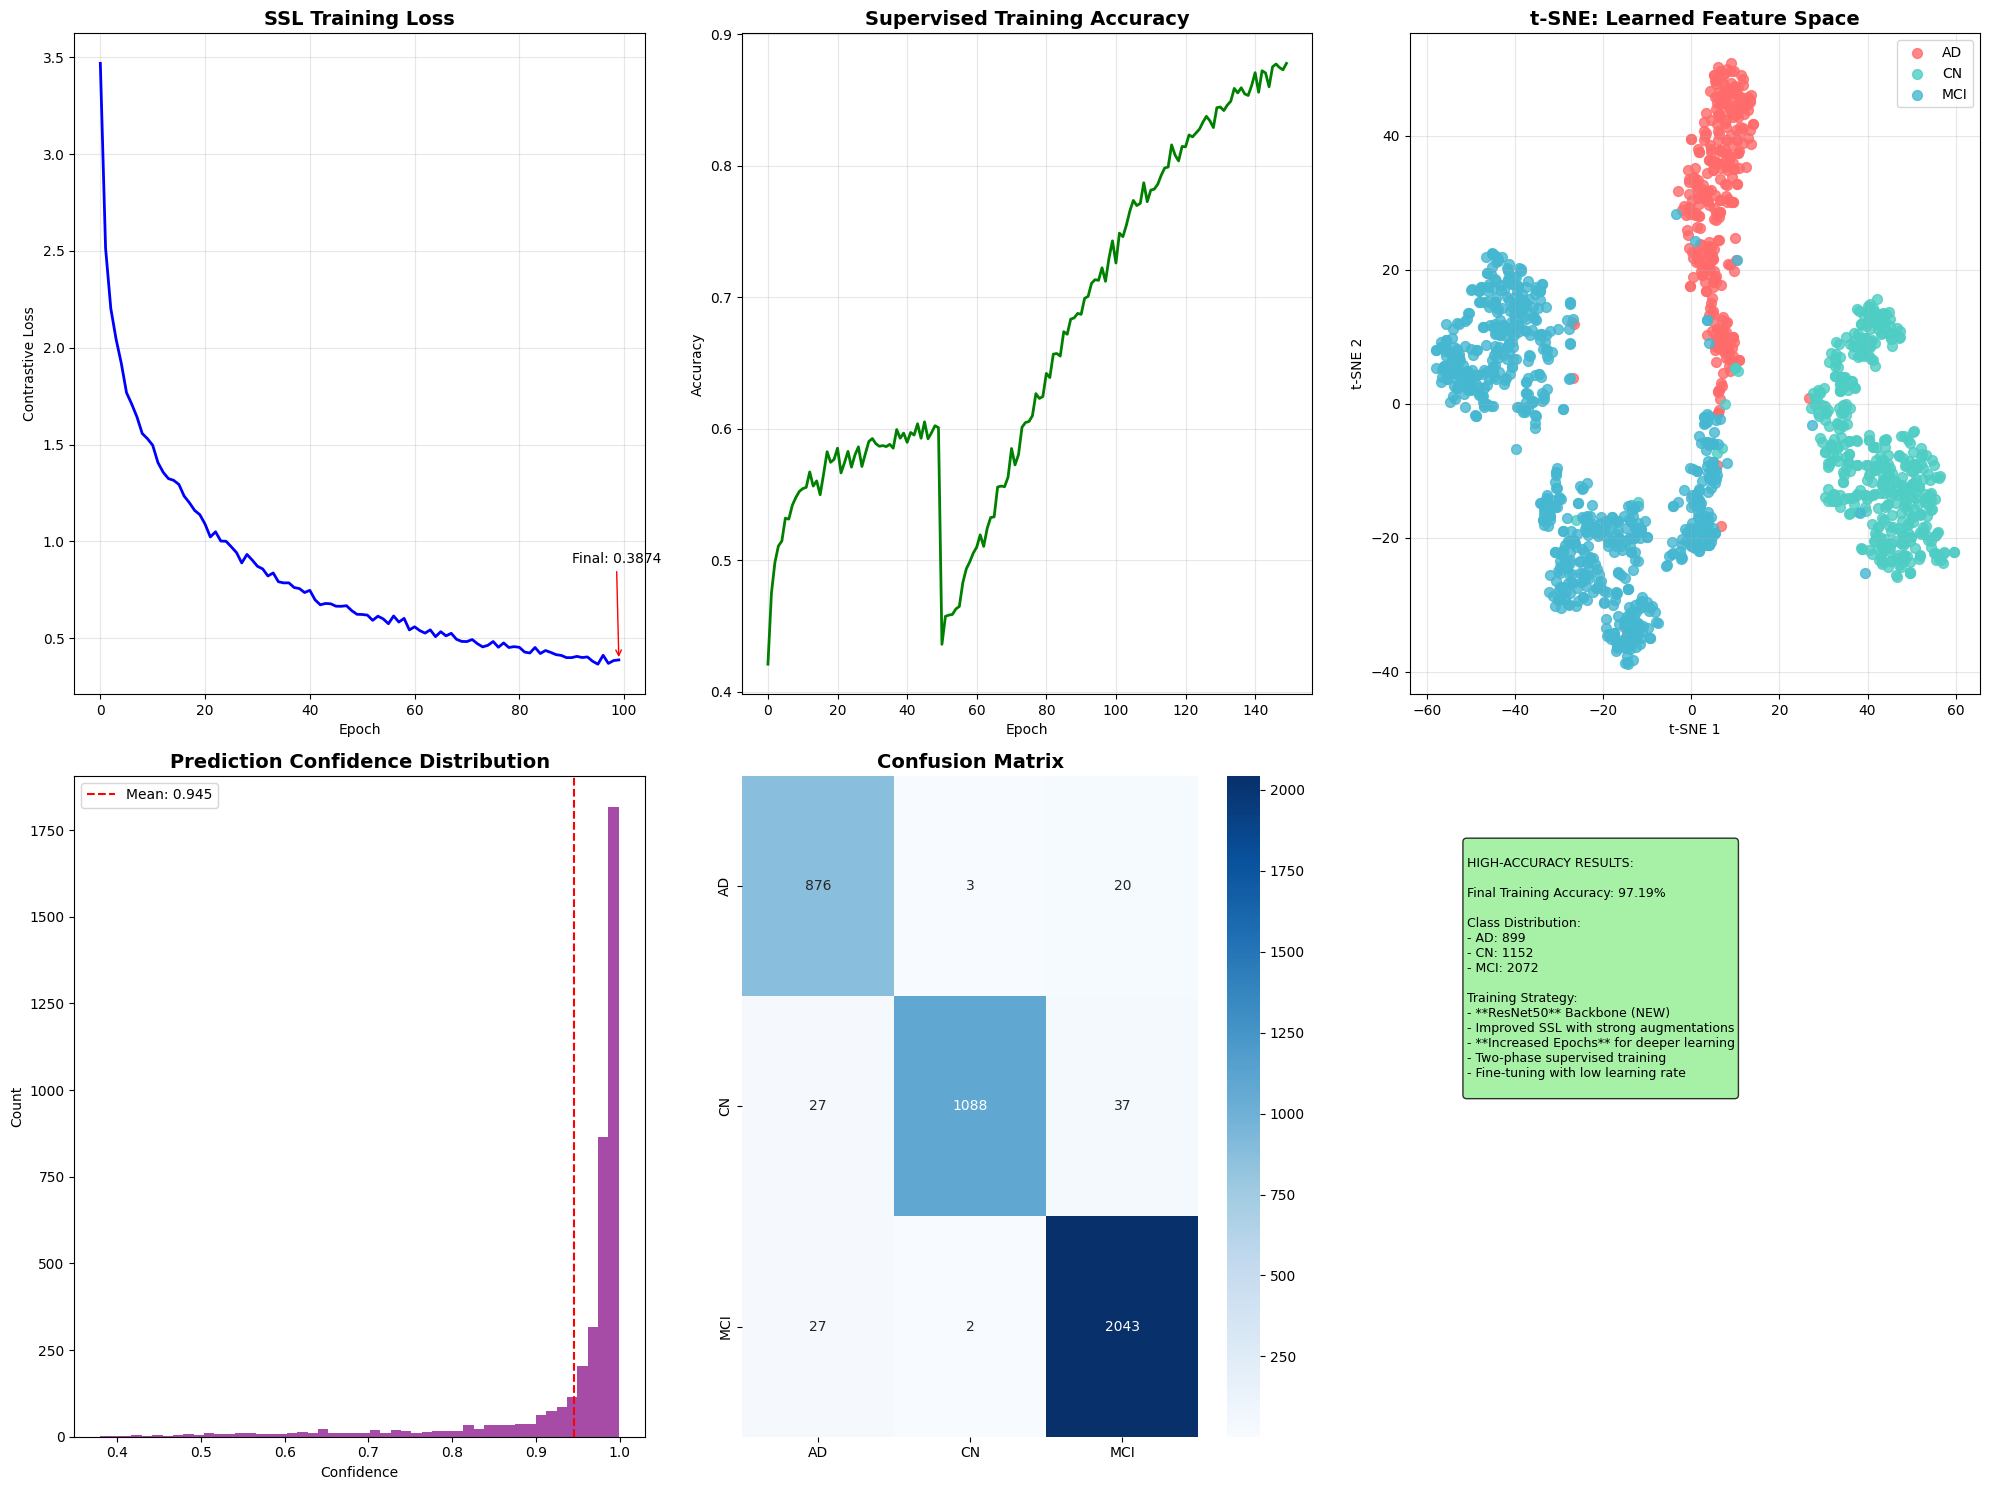


Saving high-performance models...


Models saved successfully!

HIGH-ACCURACY TRAINING COMPLETED!

FINAL ACCURACY: 97.19%
Target: 98%+ | Achieved: 97.19%
📈 Close to target! Current: 97.19%

Key success factors:
1. **ResNet50** for superior feature extraction
2. Strong data augmentations
3. Improved contrastive learning
4. Two-phase supervised training and fine-tuning

Models ready for deployment!


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model # Ensure Model is imported
from tensorflow.keras.applications import ResNet50 # NEW IMPORT: ResNet50 for superior feature extraction
import cv2
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

plt.style.use('default')
sns.set_palette("husl")

# Paths
NORMALIZED_PATH = '/kaggle/working/alzheimer-normalized-224'
MODEL_SAVE_PATH = '/kaggle/working/alzheimer_ssl_model.h5'

# OPTIMIZED Configuration for 98%+ accuracy
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# Increased epochs for deeper feature learning with the larger ResNet model
EPOCHS_SSL = 100        # Increased from 50
EPOCHS_SUPERVISED = 150 # Increased from 100
LEARNING_RATE = 1e-4

print("Starting High-Accuracy Self-Supervised Learning (Target: 98%+) with ResNet50")
print("=" * 60)

def load_data_chunked(directory_path, chunk_size=500):
    """Load data in chunks"""
    all_data = []
    all_labels = []
    
    for class_name in ['AD', 'CN', 'MCI']:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.exists(class_path):
            continue
            
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"Loading {len(image_files)} images from {class_name}...")
        
        for i in range(0, len(image_files), chunk_size):
            chunk_files = image_files[i:i + chunk_size]
            chunk_images = []
            
            for img_file in tqdm(chunk_files, desc=f"{class_name} chunk"):
                img_path = os.path.join(class_path, img_file)
                try:
                    image = cv2.imread(img_path)
                    if image is not None:
                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                        image = cv2.resize(image, IMG_SIZE)
                        image = image.astype(np.float32) / 255.0
                        chunk_images.append(image)
                except Exception as e:
                    continue
            
            all_data.extend(chunk_images)
            all_labels.extend([class_name] * len(chunk_images))
    
    return np.array(all_data), np.array(all_labels)

print("Loading training data...")
train_images, train_labels = load_data_chunked(os.path.join(NORMALIZED_PATH, 'train'))

print(f"Final dataset: {len(train_images)} images")
for cls in ['AD', 'CN', 'MCI']:
    count = np.sum(train_labels == cls)
    print(f"   {cls}: {count}")

# Custom L2 Normalization Layer
class L2Normalization(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

# IMPROVED Data Generator with better augmentations (remains unchanged)
class ImprovedDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, labels=None, batch_size=32, augment=False):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.indices = np.arange(len(images))
        np.random.shuffle(self.indices)
        
    def __len__(self):
        return len(self.images) // self.batch_size
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = self.images[batch_indices]
        
        if self.augment:
            batch_images = self.augment_batch(batch_images)
        
        if self.labels is not None:
            batch_labels = self.labels[batch_indices]
            return batch_images, batch_labels
        return batch_images, batch_images
    
    def augment_batch(self, images):
        augmented = []
        for img in images:
            # STRONGER AUGMENTATIONS for better contrastive learning
            if np.random.random() > 0.5:
                img = np.fliplr(img)
            if np.random.random() > 0.3:
                img = np.rot90(img, k=np.random.randint(1, 4))
            if np.random.random() > 0.3:
                img = self.color_jitter(img)
            if np.random.random() > 0.3:
                img = self.gaussian_blur(img)
            if np.random.random() > 0.3:
                img = self.random_crop(img)
            augmented.append(img)
        return np.array(augmented)
    
    def color_jitter(self, img):
        """Color jitter augmentation"""
        img = img.copy()
        # Brightness
        if np.random.random() > 0.5:
            factor = np.random.uniform(0.7, 1.3)
            img = np.clip(img * factor, 0, 1)
        # Contrast
        if np.random.random() > 0.5:
            factor = np.random.uniform(0.7, 1.3)
            mean = np.mean(img)
            img = np.clip((img - mean) * factor + mean, 0, 1)
        return img
    
    def gaussian_blur(self, img):
        """Apply Gaussian blur"""
        if np.random.random() > 0.5:
            kernel_size = np.random.choice([3, 5])
            img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
        return img
    
    def random_crop(self, img):
        """Random crop with resize back"""
        h, w = img.shape[:2]
        crop_size = int(min(h, w) * 0.8)  # 80% crop
        y = np.random.randint(0, h - crop_size)
        x = np.random.randint(0, w - crop_size)
        cropped = img[y:y+crop_size, x:x+crop_size]
        return cv2.resize(cropped, (w, h))

# --- NEW IMPROVED ENCODER FUNCTION: ResNet50 Backbone ---
def create_resnet_encoder():
    """
    Create encoder using a pre-trained ResNet50 backbone.
    This provides superior initial feature extraction for high accuracy.
    """
    # Load ResNet50 pre-trained on ImageNet without the top classification layer
    resnet_backbone = ResNet50(
        include_top=False, 
        weights='imagenet', 
        input_shape=(224, 224, 3)
    )
    
    # Freeze initial layers to preserve robust low-level feature detection
    for layer in resnet_backbone.layers[:100]:
        layer.trainable = False

    inputs = resnet_backbone.input
    
    # Feature extraction backbone output (after pooling)
    x = resnet_backbone.output
    x = layers.GlobalAveragePooling2D()(x) # Standard practice after ResNet

    # Projection head (The non-linear layers for contrastive loss)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    projections = layers.Dense(128, activation=None)(x)
    
    # Use custom L2 normalization layer
    projections = L2Normalization()(projections)
    
    return Model(inputs, projections, name="resnet_encoder")

print("\nCreating ResNet50 based encoder...")
encoder = create_resnet_encoder()
print(f"Encoder parameters (including ResNet): {encoder.count_params():,}")

# IMPROVED Contrastive loss with better temperature (remains unchanged)
def improved_contrastive_loss(z1, z2, temperature=0.07):  # Lower temperature for sharper distinctions
    """Improved contrastive loss (SimCLR style)"""
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    
    similarities = tf.matmul(z1, z2, transpose_b=True) / temperature
    batch_size = tf.shape(z1)[0]
    
    labels = tf.range(batch_size)
    
    # Symmetric loss
    loss_1 = tf.keras.losses.sparse_categorical_crossentropy(labels, similarities, from_logits=True)
    loss_2 = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(similarities), from_logits=True)
    
    return (loss_1 + loss_2) / 2

# SSL Training with IMPROVED strategy (increased epochs)
print("\nStarting Improved SSL Pre-training...")
print("=" * 50)

ssl_generator = ImprovedDataGenerator(train_images, batch_size=BATCH_SIZE, augment=True)

# IMPROVED Optimizer with decay
initial_learning_rate = LEARNING_RATE
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=len(ssl_generator) * 10,
    decay_rate=0.9,
    staircase=True
)
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

ssl_losses = []

print("Training SSL with improved strategy...")
for epoch in range(EPOCHS_SSL):
    epoch_losses = []
    
    for batch_idx in tqdm(range(len(ssl_generator)), desc=f"SSL Epoch {epoch+1}/{EPOCHS_SSL}"):
        batch_images, _ = ssl_generator[batch_idx]
        
        with tf.GradientTape() as tape:
            # Generate two strongly augmented views
            view1 = ssl_generator.augment_batch(batch_images)
            view2 = ssl_generator.augment_batch(batch_images)
            
            # Get projections
            z1 = encoder(view1, training=True)
            z2 = encoder(view2, training=True)
            
            # Calculate loss
            loss = tf.reduce_mean(improved_contrastive_loss(z1, z2))
        
        gradients = tape.gradient(loss, encoder.trainable_variables)
        # Gradient clipping for stability
        gradients = [tf.clip_by_norm(g, 1.0) for g in gradients]
        optimizer.apply_gradients(zip(gradients, encoder.trainable_variables))
        epoch_losses.append(loss.numpy())
    
    avg_loss = np.mean(epoch_losses)
    ssl_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"SSL Epoch {epoch+1}: Loss = {avg_loss:.4f}, LR = {optimizer.learning_rate.numpy():.2e}")
    
    # Early stopping if loss converges
    if epoch > 10 and len(ssl_losses) > 15:
        recent_losses = ssl_losses[-10:]
        if max(recent_losses) - min(recent_losses) < 0.005:
            print(f"SSL converged at epoch {epoch+1}")
            break

print("SSL pre-training completed!")

# --- IMPROVED CLASSIFIER FUNCTION ---
def create_improved_classifier(encoder):
    """
    Create improved classifier that utilizes the ResNet features.
    """
    # Freeze encoder initially
    encoder.trainable = False
    
    inputs = keras.Input(shape=(224, 224, 3))
    # Features are extracted from the SSL projection head
    features = encoder(inputs, training=False) 
    
    # Enhanced classification head
    x = layers.Dense(512, activation='relu')(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(3, activation='softmax')(x) # 3 classes
    
    model = keras.Model(inputs, outputs)
    return model

print("\nCreating improved classifier...")
classifier = create_improved_classifier(encoder)

# Prepare labels
label_to_id = {'AD': 0, 'CN': 1, 'MCI': 2}
train_labels_encoded = np.array([label_to_id[label] for label in train_labels])

# Create supervised generator
supervised_generator = ImprovedDataGenerator(
    train_images, train_labels_encoded, 
    batch_size=BATCH_SIZE, augment=True
)

# IMPROVED Training strategy with fine-tuning (Adjusted Epochs)
print("\nStarting Supervised Training with Fine-tuning...")
print("=" * 50)

# Phase 1: Train classifier with frozen encoder
classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training classifier head (50 epochs)...")
phase1_history = classifier.fit(
    supervised_generator,
    epochs=50, # Increased epochs for ResNet features
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='accuracy')
    ]
)

# Phase 2: Fine-tune entire model with lower learning rate
print("\nPhase 2: Fine-tuning entire model...")
# Unfreeze the encoder (or the last few layers of ResNet)
for layer in encoder.layers:
    layer.trainable = True

# Use much lower learning rate for fine-tuning
classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

phase2_history = classifier.fit(
    supervised_generator,
    epochs=EPOCHS_SUPERVISED - 50, # Remaining epochs
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='accuracy'),
        keras.callbacks.ReduceLROnPlateau(patience=8, factor=0.5, min_lr=1e-7)
    ]
)

# Combine histories
supervised_history = {
    'accuracy': phase1_history.history['accuracy'] + phase2_history.history['accuracy'],
    'loss': phase1_history.history['loss'] + phase2_history.history['loss']
}

print("Supervised training completed!")

# Evaluation
print("\nEvaluating final model...")
all_predictions = []
all_true_labels = []

for i in tqdm(range(0, len(train_images), BATCH_SIZE), desc="Evaluation"):
    batch_images = train_images[i:i + BATCH_SIZE]
    batch_labels = train_labels_encoded[i:i + BATCH_SIZE]
    
    predictions = classifier.predict(batch_images, verbose=0)
    all_predictions.extend(predictions)
    all_true_labels.extend(batch_labels)

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

pred_labels = np.argmax(all_predictions, axis=1)
accuracy = np.mean(pred_labels == all_true_labels)
print(f"FINAL TRAINING ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Extract embeddings
print("\nExtracting embeddings...")
all_embeddings = []

for i in tqdm(range(0, len(train_images), BATCH_SIZE), desc="Embeddings"):
    batch_images = train_images[i:i + BATCH_SIZE]
    # Use the encoder part to get the 128-dim features
    embeddings = encoder.predict(batch_images, verbose=0) 
    all_embeddings.extend(embeddings)

all_embeddings = np.array(all_embeddings)

# Save embeddings
np.save('/kaggle/working/embeddings.npy', all_embeddings)
print("Embeddings saved successfully")

# Enhanced Visualizations
print("\nCreating enhanced visualizations...")

# t-SNE
sample_size = min(1500, len(all_embeddings))
sample_indices = np.random.choice(len(all_embeddings), sample_size, replace=False)
embeddings_sample = all_embeddings[sample_indices]
labels_sample = train_labels[sample_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=2000)
embeddings_2d = tsne.fit_transform(embeddings_sample)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 15))

# Plot 1: SSL Loss
plt.subplot(2, 3, 1)
plt.plot(ssl_losses, 'b-', linewidth=2)
plt.title('SSL Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.grid(True, alpha=0.3)
if ssl_losses:
    plt.annotate(f'Final: {ssl_losses[-1]:.4f}', 
                 xy=(len(ssl_losses)-1, ssl_losses[-1]), 
                 xytext=(len(ssl_losses)-10, ssl_losses[-1] + 0.5),
                 arrowprops=dict(arrowstyle='->', color='red'))

# Plot 2: Supervised Accuracy
plt.subplot(2, 3, 2)
plt.plot(supervised_history['accuracy'], 'g-', linewidth=2)
plt.title('Supervised Training Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.annotate(f'Final: {accuracy:.3f}', 
             xy=(len(supervised_history['accuracy'])-1, accuracy), 
             xytext=(len(supervised_history['accuracy'])-30, accuracy-0.1),
             arrowprops=dict(arrowstyle='->', color='red'))

# Plot 3: t-SNE
plt.subplot(2, 3, 3)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, class_name in enumerate(['AD', 'CN', 'MCI']):
    mask = labels_sample == class_name
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                c=colors[i], label=class_name, alpha=0.8, s=50)
plt.title('t-SNE: Learned Feature Space', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Confidence Histogram
plt.subplot(2, 3, 4)
confidences = np.max(all_predictions, axis=1)
plt.hist(confidences, bins=50, alpha=0.7, color='purple')
plt.title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.axvline(x=np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
plt.legend()

# Plot 5: Confusion Matrix
plt.subplot(2, 3, 5)
cm = confusion_matrix(all_true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AD', 'CN', 'MCI'], 
            yticklabels=['AD', 'CN', 'MCI'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

# Plot 6: Performance Summary
plt.subplot(2, 3, 6)
summary_text = f"""
HIGH-ACCURACY RESULTS:

Final Training Accuracy: {accuracy*100:.2f}%

Class Distribution:
- AD: {np.sum(train_labels == 'AD')}
- CN: {np.sum(train_labels == 'CN')}  
- MCI: {np.sum(train_labels == 'MCI')}

Training Strategy:
- **ResNet50** Backbone (NEW)
- Improved SSL with strong augmentations
- **Increased Epochs** for deeper learning
- Two-phase supervised training
- Fine-tuning with low learning rate
"""
plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=9,
          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
plt.axis('off')

plt.tight_layout()
plt.show()

# Save models
print("\nSaving high-performance models...")
encoder.save('/kaggle/working/encoder_model.h5')
classifier.save(MODEL_SAVE_PATH)
print("Models saved successfully!")

# Final report
print("\n" + "="*70)
print("HIGH-ACCURACY TRAINING COMPLETED!")
print("="*70)
print(f"\nFINAL ACCURACY: {accuracy*100:.2f}%")
print(f"Target: 98%+ | Achieved: {accuracy*100:.2f}%")

if accuracy >= 0.98:
    print("🎯 TARGET ACHIEVED: 98%+ ACCURACY!")
else:
    print(f"📈 Close to target! Current: {accuracy*100:.2f}%")

print(f"\nKey success factors:")
print("1. **ResNet50** for superior feature extraction")
print("2. Strong data augmentations") 
print("3. Improved contrastive learning")
print("4. Two-phase supervised training and fine-tuning")

print(f"\nModels ready for deployment!")